<a href="https://colab.research.google.com/github/7113029018/few-shot/blob/main/2026_2_25_decen%E5%AF%A6%E4%BD%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2/25 decen

In [ ]:
!pip install -q numpy==1.26.4 transformers==4.44.2 accelerate==0.33.0 matplotlib seaborn sklearn

In [4]:
!pip install -U --force-reinstall transformers==4.44.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.7/803.7 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.

In [2]:
import numpy, transformers, accelerate, sklearn

print("numpy", numpy.__version__)
print("transformers", transformers.__version__)
print("accelerate", accelerate.__version__)
print("sklearn", sklearn.__version__)
# numpy 1.26.4
# transformers 4.44.2
# accelerate 0.33.0
# sklearn 1.6.1


numpy 2.4.2
transformers 4.44.2
accelerate 1.12.0
sklearn 1.6.1


In [32]:
import pandas as pd

# ========= 1) 檔案路徑 =========
df1_path = "/content/drive/MyDrive/DECEN/post_level_dataset_800.csv"
df2_path = "/content/drive/MyDrive/few-shot/merged_stage3_full.csv"

# ========= 2) 讀取資料 =========
df1 = pd.read_csv(df1_path)
df2 = pd.read_csv(df2_path)

print("df1 columns:", df1.columns.tolist())
print("df2 columns:", df2.columns.tolist())
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

# ========= 3) df2 取唯一 post_id + caption =========
# 只保留你需要的欄位
df2_post = df2[["post_id", "caption"]].copy()

# 去除重複（因為 df2 是 word-level，會有很多重複 post_id/caption）
df2_post = df2_post.drop_duplicates(subset=["post_id", "caption"]).reset_index(drop=True)

# 新增標籤 y=1
df2_post["y"] = 1

print("df2_post (unique post-level) shape:", df2_post.shape)
display(df2_post.head())

# ========= 4) df1 欄位整理（只保留 post-level 需要欄位） =========
# 如果 df1 已經就是 post_id, caption, y，這段也可保留當保險
df1_post = df1[["post_id", "caption", "y"]].copy()

# ========= 5) 合併 df1 + df2_post =========
merged = pd.concat([df1_post, df2_post], ignore_index=True)

# ========= 6) 去除重複（避免 df1 本來已有相同貼文） =========
# 如果同一 post_id + caption 重複，只保留第一筆
merged = merged.drop_duplicates(subset=["post_id", "caption"], keep="first").reset_index(drop=True)

print("merged shape:", merged.shape)
print("label distribution:")
print(merged["y"].value_counts(dropna=False))

display(merged.head(10))

# ========= 7) 儲存 =========
out_path = "/content/drive/MyDrive/DECEN/post_level_dataset_800_plus_syn.csv"
merged.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"✅ 已儲存：{out_path}")

df1 columns: ['post_id', 'caption', 'y']
df2 columns: ['post_id', 'caption', 'word', 'human_label', 'gpt_label_1', 'gpt_label_2', 'gpt_label_3', 'gpt_label_4', 'gpt_label_5', 'word_order']
df1 shape: (800, 3)
df2 shape: (9030, 10)
df2_post (unique post-level) shape: (200, 3)


,post_id,caption,y
0,801,你知道什麼是愛？不是一個句子，也不是一個表情符號，可能還是一個人的無法形容的感覺。今天我感到...,1
1,802,每天都有新的開始，然而每天的開始都像是一個長期無人之地。 我開始失去興趣了，我的自信心也開始...,1
2,803,每天也一樣這樣，缺乏那種興奮和對未來的期待，現在的生活像是無目的的旅行。 我開始忘記自己想要...,1
3,804,我覺得我每天都在走在灰色地帶。每天不再有那樣的興趣，我什麼也沒好好想看或玩。雖然我知道這不是...,1
4,805,我最近什麼都不想做了。 這是輕微的失望，但它讓我感到無法突破的困擾感。 這種感受似乎很常...,1


merged shape: (963, 3)
label distribution:
y
1    576
0    387
Name: count, dtype: int64


,post_id,caption,y
0,keke.lifediary,‼️更正第8項為：誠品480商場‼️\n \n👇🏻加入keke大家庭👇🏻\nKeke 帶我去...,0
1,yahoofoodhongkong,主打蛋包飯的「米青蛋包飯公司」是人氣番茄湯麵專門店「番茄師兄」的姊妹店，數月前進駐荔枝角D2...,0
2,2569713370816930416_3218617152,.\n最近每天晚上都在哭，但我並不希望停止哭泣；我最不想成為的，就是再也不會因為分離而哭的人...,1
3,hao_emo520,更新文案⬇️\n🌃進入主頁 @hao_emo520\n.\n.\n.\n#十二星座#摩羯#水...,0
4,2558235872593928150_3218617152,活著好難，活著真的真的好難。\n我不懂我做錯了什麼。,1
5,keke.lifediary,還有什麼尷尬時刻XDD??\n留言分享一下吧🙌\n\n👇🏻加入keke大家庭👇🏻\nKeke...,0
6,3194991693095595546_5611656677,｜2023.9.19｜\n⁡\n 這裡已經是我唯一的所在了，現實裡的歸屬感都沒有在這個帳號裡...,1
7,i.m_lizfish_,-\n愛笑的人運氣不會太差☺️\n-\n#日常 #街拍 #夜晚 #daily #night,0
8,amerio_daily,原來麻辣燙係米線界嘅自由斟🤣🤣\n\n我第一次可以將寬粉、薯粉、米線同粉絲等\n撈埋喺同一個...,0
9,doll.baby1314,我知道有三個人喜歡你嗎？\n我，我啊，就是我🤗\nline領取完整版🔥⏩ @571cscom...,0


✅ 已儲存：/content/drive/MyDrive/DECEN/post_level_dataset_800_plus_syn.csv


In [50]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, cohen_kappa_score, roc_auc_score
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ============================================
# 1. 全域設定與種子固定
# ============================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 路徑設定
DER_CKPT_PATH = "/content/drive/MyDrive/DECEN/best_sentence_level_bert_focal.pt"
POST_CSV = "/content/drive/MyDrive/DECEN/post_level_dataset_800_plus_syn.csv"
SAVE_DIR = "/content/drive/MyDrive/DECEN/"
PRECOMPUTED_PATH = os.path.join(SAVE_DIR, "precomputed_features.pt")
MODEL_NAME = "bert-base-chinese"

# 超參數
MAX_SENT_LEN = 128
MAX_SENTS_PER_POST = 20
EMO_DIM = 128
DD_HIDDEN = 128
BATCH_SIZE = 16 # 預算完後 Batch Size 可以調大
# LR = 1e-5 #2e-5
EPOCHS = 20

# ============================================
# 修改後的 Optimizer 設定 (分層學習率)
# ============================================
# 1. 將參數分組
# 我們希望 ecr 模組和 classifier 使用較大的 LR (1e-4)
# 其餘部分 (主要是 ctx_down 和 emo_proj) 使用較小的 LR (1e-5)
head_params = list(model.ecr.parameters()) + list(model.classifier.parameters())
base_params = [p for n, p in model.named_parameters() if "ecr" not in n and "classifier" not in n]

optimizer = torch.optim.AdamW([
    {'params': base_params, 'lr': 1e-5},      # 基礎層使用小 LR
    {'params': head_params, 'lr': 1e-4}       # ECR 與分類器使用大 LR
], weight_decay=0.01)

print(f"Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4")





# ============================================
# 2. 損失函數：Focal Loss (對齊論文 alpha=0.5)
# ============================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

# ============================================
# 3. 模型定義 (DER 與修正後的 DECEN)
# ============================================

class DER_Inference(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.classifier = nn.Linear(768, n)
    def forward(self, ids, mask):
        out = self.bert(ids, mask)
        return self.classifier(out.last_hidden_state[:, 0])

class ECR_Module(nn.Module):
    """
    對齊 DECEN 論文的 Emotion-Context Relationship 模組
    公式: alpha = softmax(v^T * tanh(W_e * Re + W_c * Rc + b))
    """
    def __init__(self, emo_dim, ctx_dim):
        super().__init__()
        self.W_e = nn.Linear(emo_dim, emo_dim)
        self.W_c = nn.Linear(ctx_dim, emo_dim)
        self.v = nn.Linear(emo_dim, 1, bias=False)

    def forward(self, Re, Rc, mask):
        # Re: (B, T, Emo_dim), Rc: (B, T, Ctx_dim)
        combined = torch.tanh(self.W_e(Re) + self.W_c(Rc)) # (B, T, Emo_dim)
        score = self.v(combined).squeeze(-1) # (B, T)
        score = score.masked_fill(~mask, -1e9)
        alpha = torch.softmax(score, dim=1) # (B, T)
        return alpha

class DECEN_Model(nn.Module):
    def __init__(self, emo_class_num, emo_dim, dd_hidden):
        super().__init__()
        self.emo_proj = nn.Linear(emo_class_num, emo_dim)
        self.ctx_down = nn.Linear(768, emo_dim) # 將 768 降維到與 emo_dim 一致以便融合

        # ECR 模組
        self.ecr = ECR_Module(emo_dim, 768)

        # DD 模組 (BiLSTM)
        self.bilstm = nn.LSTM(emo_dim, dd_hidden, batch_first=True, bidirectional=True)
        self.classifier = nn.Linear(dd_hidden * 2, 2)


    def forward(self, Rc_pad, Re_probs_pad, lengths, mask, ablation="full"):
        # 1. 情緒特徵投影
        Re_pad = self.emo_proj(Re_probs_pad) # (B, T, Emo_dim)
        Rc_low = self.ctx_down(Rc_pad)       # (B, T, Emo_dim)

        # 2. ECR 融合 (依據論文論文公式 R~ = alpha * Rc + Re)

        if ablation == "no_ecr":
            R_tilde = Rc_low + Re_pad
        elif ablation == "no_emotion":
            R_tilde = Rc_low
        elif ablation == "no_context":
            R_tilde = Re_pad
        else:
            alpha = self.ecr(Re_pad, Rc_pad, mask) # (B, T)
            R_tilde = alpha.unsqueeze(-1) * Rc_low + Re_pad

        # 3. BiLSTM 分類
        packed = nn.utils.rnn.pack_padded_sequence(R_tilde, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.bilstm(packed)
        feat = torch.cat((hn[-2], hn[-1]), dim=-1) # 拼接雙向最後狀態
        return self.classifier(feat)

# ============================================
# 4. 預處理階段：提取特徵並儲存
# ============================================

SENT_SPLIT_RE = re.compile(r'([。！？!?\n]+)')

def split_sentences(text):
    text = str(text).strip()
    if not text: return [" "]
    parts = SENT_SPLIT_RE.split(text)
    sents, buf = [], ""
    for part in parts:
        if not part: continue
        buf += part
        if SENT_SPLIT_RE.fullmatch(part):
            sents.append(buf.strip()); buf = ""
    if buf.strip(): sents.append(buf.strip())
    return sents[:MAX_SENTS_PER_POST]

def precompute_features():
    if os.path.exists(PRECOMPUTED_PATH):
        print("偵測到預算特徵，跳過預處理...")
        return torch.load(PRECOMPUTED_PATH)

    print("開始預處理：提取 BERT 與 情緒向量 (此過程僅執行一次)...")
    df = pd.read_csv(POST_CSV)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # 載入 DER 模型
    ckpt = torch.load(DER_CKPT_PATH, map_location=device)
    der_model = DER_Inference(len(ckpt["label2id"])).to(device)
    der_model.load_state_dict(ckpt["model_state"], strict=False)
    der_model.eval()

    # 載入基礎 BERT
    base_bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
    base_bert.eval()

    all_data = []

    with torch.no_grad():
        for i, row in tqdm(df.iterrows(), total=len(df)):
            sents = split_sentences(row["caption"])
            num_s = len(sents)

            # Tokenization
            inputs = tokenizer(sents, truncation=True, padding=True, max_length=MAX_SENT_LEN, return_tensors="pt").to(device)

            # 1. 提取 Context Embedding (Rc)
            outputs = base_bert(**inputs)
            Rc = outputs.last_hidden_state[:, 0, :].cpu() # (num_s, 768)

            # 2. 提取 Emotion Probs (Re)
            der_logits = der_model(inputs["input_ids"], inputs["attention_mask"])
            Re_probs = torch.softmax(der_logits, dim=-1).cpu() # (num_s, emo_class_num)

            all_data.append({
                "Rc": Rc,
                "Re_probs": Re_probs,
                "y": int(row["y"]),
                "num_s": num_s
            })

    torch.save(all_data, PRECOMPUTED_PATH)
    return all_data

# ============================================
# 5. 訓練用 Dataset 與 DataLoader
# ============================================

class PrecomputedDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def precomputed_collate_fn(batch):
    B = len(batch)
    lengths = torch.tensor([b["num_s"] for b in batch], dtype=torch.long)
    T_max = lengths.max().item()

    ctx_dim = batch[0]["Rc"].shape[1]
    emo_dim = batch[0]["Re_probs"].shape[1]

    Rc_pad = torch.zeros((B, T_max, ctx_dim))
    Re_probs_pad = torch.zeros((B, T_max, emo_dim))
    mask = torch.zeros((B, T_max), dtype=torch.bool)
    ys = torch.tensor([b["y"] for b in batch], dtype=torch.long)

    for i, b in enumerate(batch):
        l = b["num_s"]
        Rc_pad[i, :l] = b["Rc"]
        Re_probs_pad[i, :l] = b["Re_probs"]
        mask[i, :l] = True

    return {
        "Rc": Rc_pad.to(device),
        "Re_probs": Re_probs_pad.to(device),
        "lengths": lengths.to(device),
        "mask": mask.to(device),
        "ys": ys.to(device)
    }

# ============================================
# 6. 主執行程式
# ============================================


# 第一步：預算
all_precomputed_data = precompute_features()

# 第二步：切割資料
train_data, test_data = train_test_split(all_precomputed_data, test_size=0.2, random_state=42)

# 第三步：實驗迴圈
SEEDS = [1, 7, 13, 21, 42]
ABLATION_MODES = ["full", "no_ecr", "no_emotion", "no_context"]
all_results = []

# 取得情緒類別數量 (從預算資料中取得)
emo_class_num = all_precomputed_data[0]["Re_probs"].shape[1]

for mode in ABLATION_MODES:
    for seed in SEEDS:
        print(f"\n>>> 執行: 模式={mode}, Seed={seed} <<<")
        seed_everything(seed)

        train_loader = DataLoader(PrecomputedDataset(train_data), batch_size=BATCH_SIZE, shuffle=True, collate_fn=precomputed_collate_fn)
        test_loader = DataLoader(PrecomputedDataset(test_data), batch_size=BATCH_SIZE, collate_fn=precomputed_collate_fn)

        model = DECEN_Model(emo_class_num, EMO_DIM, DD_HIDDEN).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
        criterion = FocalLoss(alpha=0.5) # 對齊論文

        best_f1 = -1

        for epoch in range(EPOCHS):
            model.train()
            for batch in train_loader:
                logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation=mode)
                loss = criterion(logits, batch["ys"])
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            # 評估
            model.eval()
            all_preds, all_labels, all_probs = [], [], []
            with torch.no_grad():
                for batch in test_loader:
                    out = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation=mode)
                    all_probs.extend(torch.softmax(out, dim=-1)[:, 1].cpu().numpy())
                    all_preds.extend(out.argmax(dim=-1).cpu().numpy())
                    all_labels.extend(batch["ys"].cpu().numpy())

            p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_metrics = {
                    "mode": mode, "seed": seed, "f1": f1, "precision": p, "recall": r,
                    "accuracy": accuracy_score(all_labels, all_preds),
                    "kappa": cohen_kappa_score(all_labels, all_preds),
                    "auc": roc_auc_score(all_labels, all_probs)
                }

        all_results.append(best_metrics)
        print(f"完成! Best F1: {best_f1:.4f}")

# 顯示最終結果
results_df = pd.DataFrame(all_results)
print("\n--- 實驗總結報告 ---")
print(results_df.groupby("mode").agg(["mean", "std"]).drop(columns="seed"))

Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4
偵測到預算特徵，跳過預處理...

>>> 執行: 模式=full, Seed=1 <<<
完成! Best F1: 0.9617

>>> 執行: 模式=full, Seed=7 <<<
完成! Best F1: 0.9627

>>> 執行: 模式=full, Seed=13 <<<
完成! Best F1: 0.9620

>>> 執行: 模式=full, Seed=21 <<<
完成! Best F1: 0.9620

>>> 執行: 模式=full, Seed=42 <<<
完成! Best F1: 0.9587

>>> 執行: 模式=no_ecr, Seed=1 <<<
完成! Best F1: 0.9833

>>> 執行: 模式=no_ecr, Seed=7 <<<
完成! Best F1: 0.9791

>>> 執行: 模式=no_ecr, Seed=13 <<<
完成! Best F1: 0.9750

>>> 執行: 模式=no_ecr, Seed=21 <<<
完成! Best F1: 0.9791

>>> 執行: 模式=no_ecr, Seed=42 <<<
完成! Best F1: 0.9833

>>> 執行: 模式=no_emotion, Seed=1 <<<
完成! Best F1: 0.9789

>>> 執行: 模式=no_emotion, Seed=7 <<<
完成! Best F1: 0.9831

>>> 執行: 模式=no_emotion, Seed=13 <<<
完成! Best F1: 0.9748

>>> 執行: 模式=no_emotion, Seed=21 <<<
完成! Best F1: 0.9832

>>> 執行: 模式=no_emotion, Seed=42 <<<
完成! Best F1: 0.9793

>>> 執行: 模式=no_context, Seed=1 <<<
完成! Best F1: 0.9244

>>> 執行: 模式=no_context, Seed=7 <<<
完成! Best F1: 0.8988

>>> 執行: 模式=no_context, Seed=13 <<

In [34]:
#套用殘差修正 將 FocalLoss(alpha=0.75)，引入 Dropout 保護 ECR 模組，並將EPOCHS 從 10 增加到20
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, cohen_kappa_score, roc_auc_score
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ============================================
# 1. 全域設定與種子固定
# ============================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 路徑設定
DER_CKPT_PATH = "/content/drive/MyDrive/DECEN/best_sentence_level_bert_focal.pt"
POST_CSV = "/content/drive/MyDrive/DECEN/post_level_dataset_800_plus_syn.csv"
SAVE_DIR = "/content/drive/MyDrive/DECEN/"
PRECOMPUTED_PATH = os.path.join(SAVE_DIR, "precomputed_features.pt")
MODEL_NAME = "bert-base-chinese"

# 超參數
MAX_SENT_LEN = 128
MAX_SENTS_PER_POST = 20
EMO_DIM = 128
DD_HIDDEN = 128
BATCH_SIZE = 16 # 預算完後 Batch Size 可以調大
# LR = 1e-5 #2e-5
EPOCHS = 10

# ============================================
# 修改後的 Optimizer 設定 (分層學習率)
# ============================================

# 1. 將參數分組
# 我們希望 ecr 模組和 classifier 使用較大的 LR (1e-4)
# 其餘部分 (主要是 ctx_down 和 emo_proj) 使用較小的 LR (1e-5)
head_params = list(model.ecr.parameters()) + list(model.classifier.parameters())
base_params = [p for n, p in model.named_parameters() if "ecr" not in n and "classifier" not in n]

optimizer = torch.optim.AdamW([
    {'params': base_params, 'lr': 1e-5},      # 基礎層使用小 LR
    {'params': head_params, 'lr': 1e-4}       # ECR 與分類器使用大 LR
], weight_decay=0.01)

print(f"Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4")




# ============================================
# 2. 損失函數：Focal Loss (對齊論文 alpha=0.5)
# ============================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

# ============================================
# 3. 模型定義 (DER 與修正後的 DECEN)
# ============================================

class DER_Inference(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.classifier = nn.Linear(768, n)
    def forward(self, ids, mask):
        out = self.bert(ids, mask)
        return self.classifier(out.last_hidden_state[:, 0])

class ECR_Module(nn.Module):
    """
    對齊 DECEN 論文的 Emotion-Context Relationship 模組
    公式: alpha = softmax(v^T * tanh(W_e * Re + W_c * Rc + b))
    """
    def __init__(self, emo_dim, ctx_dim):
        super().__init__()
        self.W_e = nn.Linear(emo_dim, emo_dim)
        self.W_c = nn.Linear(ctx_dim, emo_dim)
        self.v = nn.Linear(emo_dim, 1, bias=False)
        # self.dropout = nn.Dropout(0.1) # 加入這行

    def forward(self, Re, Rc, mask):
        # Re: (B, T, Emo_dim), Rc: (B, T, Ctx_dim)
        combined = torch.tanh(self.W_e(Re) + self.W_c(Rc)) # (B, T, Emo_dim)
        # combined = self.dropout(combined) # 加入這行
        score = self.v(combined).squeeze(-1) # (B, T)
        score = score.masked_fill(~mask, -1e9)
        alpha = torch.softmax(score, dim=1) # (B, T)
        return alpha

class DECEN_Model(nn.Module):
    def __init__(self, emo_class_num, emo_dim, dd_hidden):
        super().__init__()
        self.emo_proj = nn.Linear(emo_class_num, emo_dim)
        self.ctx_down = nn.Linear(768, emo_dim)

        self.ecr = ECR_Module(emo_dim, 768)
        self.bilstm = nn.LSTM(emo_dim, dd_hidden, batch_first=True, bidirectional=True)

        # 增加一個 LayerNorm 穩定特徵分布
        self.norm = nn.LayerNorm(emo_dim)
        self.classifier = nn.Linear(dd_hidden * 2, 2)

    def forward(self, Rc_pad, Re_probs_pad, lengths, mask, ablation="full"):
        Re_pad = self.emo_proj(Re_probs_pad) # (B, T, Emo_dim)
        Rc_low = self.ctx_down(Rc_pad)       # (B, T, Emo_dim)

        if ablation == "full":
            alpha = self.ecr(Re_pad, Rc_pad, mask) # (B, T)
            # 修正：殘差結構。Rc_low 是主幹，alpha 調節 Re_pad 的注入
            # 這樣即便 alpha 學不好，Rc_low 的訊息也能完整保留
            R_tilde = self.norm(Rc_low + (alpha.unsqueeze(-1) * Re_pad))

        elif ablation == "no_ecr":
            R_tilde = self.norm(Rc_low + Re_pad)
        elif ablation == "no_emotion":
            R_tilde = Rc_low
        elif ablation == "no_context":
            R_tilde = Re_pad
        else:
            R_tilde = Rc_low

        packed = nn.utils.rnn.pack_padded_sequence(R_tilde, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.bilstm(packed)
        feat = torch.cat((hn[-2], hn[-1]), dim=-1)
        return self.classifier(feat)

# ============================================
# 4. 預處理階段：提取特徵並儲存
# ============================================

SENT_SPLIT_RE = re.compile(r'([。！？!?\n]+)')

def split_sentences(text):
    text = str(text).strip()
    if not text: return [" "]
    parts = SENT_SPLIT_RE.split(text)
    sents, buf = [], ""
    for part in parts:
        if not part: continue
        buf += part
        if SENT_SPLIT_RE.fullmatch(part):
            sents.append(buf.strip()); buf = ""
    if buf.strip(): sents.append(buf.strip())
    return sents[:MAX_SENTS_PER_POST]

def precompute_features():
    if os.path.exists(PRECOMPUTED_PATH):
        print("偵測到預算特徵，跳過預處理...")
        return torch.load(PRECOMPUTED_PATH)

    print("開始預處理：提取 BERT 與 情緒向量 (此過程僅執行一次)...")
    df = pd.read_csv(POST_CSV)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # 載入 DER 模型
    ckpt = torch.load(DER_CKPT_PATH, map_location=device)
    der_model = DER_Inference(len(ckpt["label2id"])).to(device)
    der_model.load_state_dict(ckpt["model_state"], strict=False)
    der_model.eval()

    # 載入基礎 BERT
    base_bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
    base_bert.eval()

    all_data = []

    with torch.no_grad():
        for i, row in tqdm(df.iterrows(), total=len(df)):
            sents = split_sentences(row["caption"])
            num_s = len(sents)

            # Tokenization
            inputs = tokenizer(sents, truncation=True, padding=True, max_length=MAX_SENT_LEN, return_tensors="pt").to(device)

            # 1. 提取 Context Embedding (Rc)
            outputs = base_bert(**inputs)
            Rc = outputs.last_hidden_state[:, 0, :].cpu() # (num_s, 768)

            # 2. 提取 Emotion Probs (Re)
            der_logits = der_model(inputs["input_ids"], inputs["attention_mask"])
            Re_probs = torch.softmax(der_logits, dim=-1).cpu() # (num_s, emo_class_num)

            all_data.append({
                "Rc": Rc,
                "Re_probs": Re_probs,
                "y": int(row["y"]),
                "num_s": num_s
            })

    torch.save(all_data, PRECOMPUTED_PATH)
    return all_data

# ============================================
# 5. 訓練用 Dataset 與 DataLoader
# ============================================

class PrecomputedDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def precomputed_collate_fn(batch):
    B = len(batch)
    lengths = torch.tensor([b["num_s"] for b in batch], dtype=torch.long)
    T_max = lengths.max().item()

    ctx_dim = batch[0]["Rc"].shape[1]
    emo_dim = batch[0]["Re_probs"].shape[1]

    Rc_pad = torch.zeros((B, T_max, ctx_dim))
    Re_probs_pad = torch.zeros((B, T_max, emo_dim))
    mask = torch.zeros((B, T_max), dtype=torch.bool)
    ys = torch.tensor([b["y"] for b in batch], dtype=torch.long)

    for i, b in enumerate(batch):
        l = b["num_s"]
        Rc_pad[i, :l] = b["Rc"]
        Re_probs_pad[i, :l] = b["Re_probs"]
        mask[i, :l] = True

    return {
        "Rc": Rc_pad.to(device),
        "Re_probs": Re_probs_pad.to(device),
        "lengths": lengths.to(device),
        "mask": mask.to(device),
        "ys": ys.to(device)
    }

# ============================================
# 6. 主執行程式
# ============================================

# 第一步：預算
all_precomputed_data = precompute_features()

# 第二步：切割資料
train_data, test_data = train_test_split(all_precomputed_data, test_size=0.2, random_state=42)

# 第三步：實驗迴圈
SEEDS = [1, 7, 13, 21, 42]
ABLATION_MODES = ["full", "no_ecr", "no_emotion", "no_context"]
all_results = []

# 取得情緒類別數量 (從預算資料中取得)
emo_class_num = all_precomputed_data[0]["Re_probs"].shape[1]

for mode in ABLATION_MODES:
    for seed in SEEDS:
        print(f"\n>>> 執行: 模式={mode}, Seed={seed} <<<")
        seed_everything(seed)

        train_loader = DataLoader(PrecomputedDataset(train_data), batch_size=BATCH_SIZE, shuffle=True, collate_fn=precomputed_collate_fn)
        test_loader = DataLoader(PrecomputedDataset(test_data), batch_size=BATCH_SIZE, collate_fn=precomputed_collate_fn)

        model = DECEN_Model(emo_class_num, EMO_DIM, DD_HIDDEN).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
        criterion = FocalLoss(alpha=0.5) # 對齊論文
        # criterion = FocalLoss(alpha=0.75, gamma=2.0) # 提高 alpha 以補償 Recall
        best_f1 = -1

        for epoch in range(EPOCHS):
            model.train()
            for batch in train_loader:
                logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation=mode)
                loss = criterion(logits, batch["ys"])
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            # 評估
            model.eval()
            all_preds, all_labels, all_probs = [], [], []
            with torch.no_grad():
                for batch in test_loader:
                    out = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation=mode)
                    all_probs.extend(torch.softmax(out, dim=-1)[:, 1].cpu().numpy())
                    all_preds.extend(out.argmax(dim=-1).cpu().numpy())
                    all_labels.extend(batch["ys"].cpu().numpy())

            p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_metrics = {
                    "mode": mode, "seed": seed, "f1": f1, "precision": p, "recall": r,
                    "accuracy": accuracy_score(all_labels, all_preds),
                    "kappa": cohen_kappa_score(all_labels, all_preds),
                    "auc": roc_auc_score(all_labels, all_probs)
                }

        all_results.append(best_metrics)
        print(f"完成! Best F1: {best_f1:.4f}")

# 顯示最終結果
results_df = pd.DataFrame(all_results)
print("\n--- 實驗總結報告 ---")
print(results_df.groupby("mode").agg(["mean", "std"]).drop(columns="seed"))

Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4
開始預處理：提取 BERT 與 情緒向量 (此過程僅執行一次)...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
100%|██████████| 963/963 [01:10<00:00, 13.67it/s]



>>> 執行: 模式=full, Seed=1 <<<
完成! Best F1: 0.9672

>>> 執行: 模式=full, Seed=7 <<<
完成! Best F1: 0.9627

>>> 執行: 模式=full, Seed=13 <<<
完成! Best F1: 0.9667

>>> 執行: 模式=full, Seed=21 <<<
完成! Best F1: 0.9710

>>> 執行: 模式=full, Seed=42 <<<
完成! Best F1: 0.9789

>>> 執行: 模式=no_ecr, Seed=1 <<<
完成! Best F1: 0.9672

>>> 執行: 模式=no_ecr, Seed=7 <<<
完成! Best F1: 0.9547

>>> 執行: 模式=no_ecr, Seed=13 <<<
完成! Best F1: 0.9630

>>> 執行: 模式=no_ecr, Seed=21 <<<
完成! Best F1: 0.9669

>>> 執行: 模式=no_ecr, Seed=42 <<<
完成! Best F1: 0.9672

>>> 執行: 模式=no_emotion, Seed=1 <<<
完成! Best F1: 0.9672

>>> 執行: 模式=no_emotion, Seed=7 <<<
完成! Best F1: 0.9587

>>> 執行: 模式=no_emotion, Seed=13 <<<
完成! Best F1: 0.9551

>>> 執行: 模式=no_emotion, Seed=21 <<<
完成! Best F1: 0.9672

>>> 執行: 模式=no_emotion, Seed=42 <<<
完成! Best F1: 0.9623

>>> 執行: 模式=no_context, Seed=1 <<<
完成! Best F1: 0.9244

>>> 執行: 模式=no_context, Seed=7 <<<
完成! Best F1: 0.8988

>>> 執行: 模式=no_context, Seed=13 <<<
完成! Best F1: 0.9177

>>> 執行: 模式=no_context, Seed=21 <<<
完成! Best F1: 0

In [51]:
#使用溫度校準 (T=0.1)：讓機率分布重新回歸到強大的雙峰分布（0.9與0.1）。
#採用百分位數門檻：自動找出最可靠的 Top 10% 樣本。
#輸出標註建議 CSV
import pandas as pd
import numpy as np
import torch

def run_semi_auto_labeling(model, unlabeled_loader, device, temperature=0.1, top_k_percent=0.1):
    model.eval()
    all_probs = []

    print(f"正在對未標註資料進行推論 (使用溫度校準 T={temperature})...")

    with torch.no_grad():
        for batch in unlabeled_loader:
            # 獲取原始 Logits
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")

            # 套用溫度校準：Logits / T
            # T < 1 會拉大差距，讓機率更兩極化
            probs = torch.softmax(logits / temperature, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)

    # 計算百分位數門檻 (基於你的分布)
    upper_bound = np.percentile(all_probs, 100 * (1 - top_k_percent))
    lower_bound = np.percentile(all_probs, 100 * top_k_percent)

    print(f"--- 標註決策報告 ---")
    print(f"經過溫度校準後的機率最大值: {all_probs.max():.4f}")
    print(f"經過溫度校準後的機率最小值: {all_probs.min():.4f}")
    print(f"建議抑鬱門檻 (Top {top_k_percent*100}%): p > {upper_bound:.4f}")
    print(f"建議健康門檻 (Bottom {top_k_percent*100}%): p < {lower_bound:.4f}")

    return all_probs, upper_bound, lower_bound

# 假設你有一份未標註的 dataframe: df_unlabeled
# probs, up, low = run_semi_auto_labeling(model, unlabeled_loader, device)

# df_unlabeled['p_depression'] = probs
# df_unlabeled['pseudo_label'] = -1  # 先預設為未標註
# df_unlabeled.loc[df_unlabeled['p_depression'] > up, 'pseudo_label'] = 1
# df_unlabeled.loc[df_unlabeled['p_depression'] < low, 'pseudo_label'] = 0

# # 儲存結果
# df_labeled = df_unlabeled[df_unlabeled['pseudo_label'] != -1]
# df_labeled.to_csv("pseudo_labeled_data.csv", index=False)

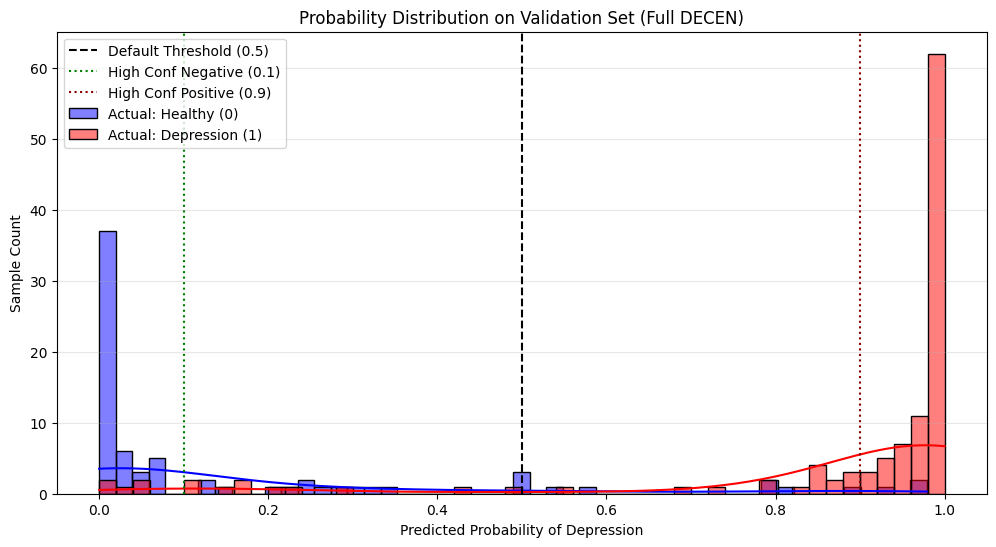

--- 驗證集信心度報告 ---
總樣本數: 193
信心度 > 0.9 的樣本數: 91 筆
  其中標註正確 (True Positive): 88
  其中標註錯誤 (False Positive): 3 (若為 0 則標註極安全)

信心度 < 0.1 的樣本數: 56 筆
  其中標註正確 (True Negative): 51
  其中標註錯誤 (False Negative): 5


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def check_val_distribution(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # 使用 Full 模式
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")
            # probs = torch.softmax(logits, dim=-1)[:, 1] # 取得抑鬱類別 (label=1) 的機率
            probs = torch.softmax(logits / 0.1, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["ys"].cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # 繪製圖表
    plt.figure(figsize=(12, 6))

    # 繪製不同標籤的分布
    sns.histplot(all_probs[all_labels == 0], bins=50, color='blue', label='Actual: Healthy (0)', kde=True, alpha=0.5)
    sns.histplot(all_probs[all_labels == 1], bins=50, color='red', label='Actual: Depression (1)', kde=True, alpha=0.5)

    plt.title("Probability Distribution on Validation Set (Full DECEN)")
    plt.xlabel("Predicted Probability of Depression")
    plt.ylabel("Sample Count")
    plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
    plt.axvline(x=0.1, color='green', linestyle=':', label='High Conf Negative (0.1)')
    plt.axvline(x=0.9, color='darkred', linestyle=':', label='High Conf Positive (0.9)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # 統計區間
    total = len(all_probs)
    correct_high_p = np.sum((all_probs > 0.9) & (all_labels == 1))
    wrong_high_p = np.sum((all_probs > 0.9) & (all_labels == 0))

    print(f"--- 驗證集信心度報告 ---")
    print(f"總樣本數: {total}")
    print(f"信心度 > 0.9 的樣本數: {np.sum(all_probs > 0.9)} 筆")
    print(f"  其中標註正確 (True Positive): {correct_high_p}")
    print(f"  其中標註錯誤 (False Positive): {wrong_high_p} (若為 0 則標註極安全)")
    print(f"\n信心度 < 0.1 的樣本數: {np.sum(all_probs < 0.1)} 筆")
    print(f"  其中標註正確 (True Negative): {np.sum((all_probs < 0.1) & (all_labels == 0))}")
    print(f"  其中標註錯誤 (False Negative): {np.sum((all_probs < 0.1) & (all_labels == 1))}")

# 呼叫
check_val_distribution(model, test_loader, device)

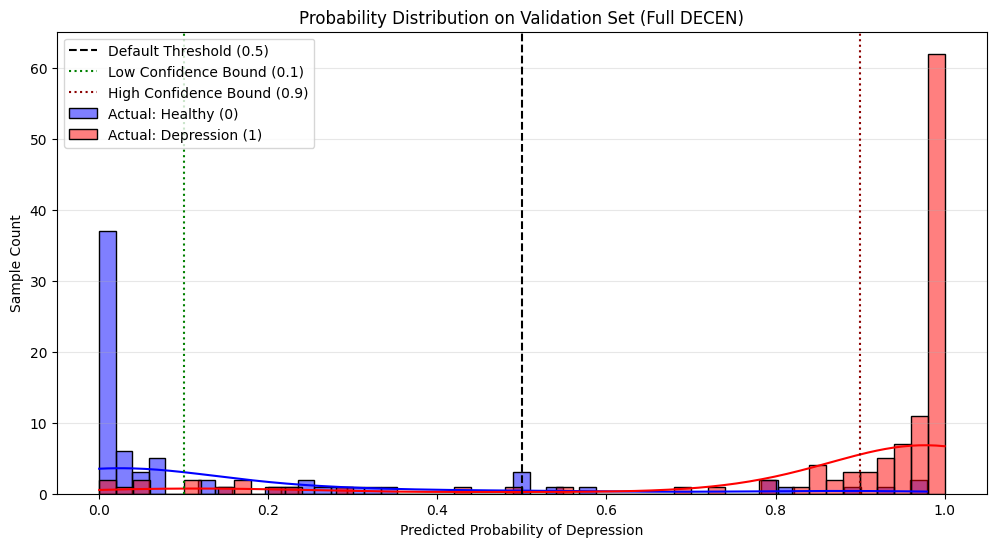

--- 驗證集信心度報告 ---
總樣本數: 193
信心度 > 0.7 (預測抑鬱): 108 筆
  - 正確標記 (True Positive): 101
  - 錯誤標記 (False Positive): 7

信心度 < 0.3 (預測健康): 73 筆
  - 正確標記 (True Negative): 60
  - 錯誤標記 (False Negative): 13

模糊地帶 (0.3 <= p <= 0.7): 12 筆 (建議人工覆核區)


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def check_val_distribution(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # 確保使用 Full DECEN 模式
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")
            # probs = torch.softmax(logits, dim=-1)[:, 1] # 取得 label=1 (抑鬱) 的機率
            probs = torch.softmax(logits / 0.1, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["ys"].cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # 繪製圖表
    plt.figure(figsize=(12, 6))

    # 繪製健康樣本 (Label 0) 的分布
    sns.histplot(all_probs[all_labels == 0], bins=50, color='blue', label='Actual: Healthy (0)', kde=True, alpha=0.5)
    # 繪製抑鬱樣本 (Label 1) 的分布
    sns.histplot(all_probs[all_labels == 1], bins=50, color='red', label='Actual: Depression (1)', kde=True, alpha=0.5)

    plt.title("Probability Distribution on Validation Set (Full DECEN)")
    plt.xlabel("Predicted Probability of Depression")
    plt.ylabel("Sample Count")
    plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
    plt.axvline(x=0.1, color='green', linestyle=':', label='Low Confidence Bound (0.1)')
    plt.axvline(x=0.9, color='darkred', linestyle=':', label='High Confidence Bound (0.9)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # 統計報告
    total = len(all_probs)
    high_p_mask = all_probs > 0.7
    low_p_mask = all_probs < 0.3

    print(f"--- 驗證集信心度報告 ---")
    print(f"總樣本數: {total}")
    print(f"信心度 > 0.7 (預測抑鬱): {np.sum(high_p_mask)} 筆")
    print(f"  - 正確標記 (True Positive): {np.sum((high_p_mask) & (all_labels == 1))}")
    print(f"  - 錯誤標記 (False Positive): {np.sum((high_p_mask) & (all_labels == 0))}")

    print(f"\n信心度 < 0.3 (預測健康): {np.sum(low_p_mask)} 筆")
    print(f"  - 正確標記 (True Negative): {np.sum((low_p_mask) & (all_labels == 0))}")
    print(f"  - 錯誤標記 (False Negative): {np.sum((low_p_mask) & (all_labels == 1))}")

    mid_count = np.sum((all_probs >= 0.3) & (all_probs <= 0.7))
    print(f"\n模糊地帶 (0.3 <= p <= 0.7): {mid_count} 筆 (建議人工覆核區)")

# 執行檢查
check_val_distribution(model, test_loader, device)

In [49]:
# 請在執行完 check_val_distribution 後執行
print("前 10 筆預測機率值:", all_probs[:10])
print("機率最大值:", np.max(all_probs))
print("機率最小值:", np.min(all_probs))
print("機率平均值:", np.mean(all_probs))

前 10 筆預測機率值: [np.float32(0.5061882), np.float32(0.46271566), np.float32(0.63718975), np.float32(0.53993857), np.float32(0.48049203), np.float32(0.49022263), np.float32(0.48965237), np.float32(0.4600496), np.float32(0.4768461), np.float32(0.48159322)]
機率最大值: 0.65266645
機率最小值: 0.45457962
機率平均值: 0.5247134


# 原來的1204

In [2]:
!pip install -U "transformers==4.47.1" "accelerate==0.33.0" "huggingface_hub>=0.24.0" "sentencepiece"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling toke

In [ ]:
import transformers
import accelerate
import huggingface_hub

print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)


transformers: 4.57.3
accelerate: 1.12.0
huggingface_hub: 0.36.0


In [ ]:
!pip -q install gensim jieba pytorch-crf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import jieba
import jieba.posseg as pseg
import numpy as np

# 1. 讀取您的 CSV
df = pd.read_csv("/content/drive/MyDrive/select_de_synold_filtered.csv")

# 確保 word 欄位是字串 (處理可能的 NaN)
df['word'] = df['word'].astype(str)

# 2. 依據 post_id 分組，將資料轉為句子層級
sentences_data = []

# 建立一個簡單的詞性標註函數 (fallback 用)
def get_pos_single(word):
    # 如果無法對齊，則對單詞單獨標註 (權宜之計)
    pair = list(pseg.cut(word))
    if pair:
        return pair[0].flag
    return 'x'

print("正在進行 POS Tagging 與資料格式化...")

for post_id, group in df.groupby('post_id'):
    # 獲取該篇貼文的原始資料
    original_words = group['word'].tolist()
    labels = group['human_label'].tolist()
    caption = group['caption'].iloc[0]

    # 嘗試對整句進行 POS Tagging 以獲得上下文特徵
    # 注意：這一步是為了讓詞性更準確。
    # 如果 Jieba 的分詞結果與您的 original_words 不一致，我們需要處理對齊。
    # 這裡採用簡單策略：如果長度一致直接用，不一致則退回單詞標註。

    jieba_pairs = list(pseg.cut(caption))
    jieba_words = [p.word for p in jieba_pairs]
    jieba_flags = [p.flag for p in jieba_pairs]

    pos_tags = []

    # 簡單的對齊檢查 (檢查分詞結果是否與資料庫中的一樣)
    if jieba_words == original_words:
        pos_tags = jieba_flags
    else:
        # 如果 Jieba 這次分詞跟資料庫裡的不一樣，我們對每個詞單獨取詞性
        # 雖然少了上下文，但能確保資料長度正確
        pos_tags = [get_pos_single(w) for w in original_words]

    sentences_data.append({
        'post_id': post_id,
        'tokens': original_words,
        'pos': pos_tags,
        'labels': labels
    })

print(f"處理完成！共有 {len(sentences_data)} 筆貼文資料。")
# 查看第一筆資料範例
print(sentences_data[0])

正在進行 POS Tagging 與資料格式化...
處理完成！共有 664 筆貼文資料。
{'post_id': 3, 'tokens': ['心情', '情緒', '部份', '一直', '覺得', '哪裡', '怪怪的', '（', '？', '）', '我', '不', '舒服', '我', '不舒服', '、', '我', '好', '累', '我', '好累', '💤'], 'pos': ['n', 'n', 'n', 'd', 'v', 'r', 'z', 'x', 'x', 'x', 'r', 'd', 'a', 'r', 'd', 'x', 'r', 'a', 'a', 'r', 'a', 'x'], 'labels': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-D', 'E-D', 'O', 'S-D', 'O', 'B-D', 'M-D', 'E-D', 'B-D', 'E-D', 'O']}


In [ ]:
from collections import Counter

# 1. 建立詞彙表 (Vocabulary)
def build_vocab(sequences, min_freq=1, pad_token='<PAD>', unk_token='<UNK>'):
    counter = Counter()
    for seq in sequences:
        counter.update(seq)

    # 初始化字典
    vocab = {pad_token: 0, unk_token: 1}

    for token, count in counter.items():
        if count >= min_freq:
            # 【關鍵修正】檢查 token 是否已存在 (避免 O 被重複加入或覆蓋)
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab

# 收集所有的 tokens, pos, labels
all_tokens = [item['tokens'] for item in sentences_data]
all_pos = [item['pos'] for item in sentences_data]
all_labels = [item['labels'] for item in sentences_data]

# 建立 mappings
word2idx = build_vocab(all_tokens, min_freq=2) # 出現少於2次的字視為 <UNK>
pos2idx = build_vocab(all_pos, min_freq=1)

# 注意：Label 的 <UNK> 設為 'O' (非情緒)，避免預測錯誤
tag2idx = build_vocab(all_labels, min_freq=1, pad_token='<PAD>', unk_token='O')
print("=== 修正後的字典檢查 ===")
print(f"tag2idx: {tag2idx}")

# 再次檢查是否有重複 ID
ids = list(tag2idx.values())
if len(ids) != len(set(ids)):
    print("❌ 錯誤：仍然有重複的 ID！")
else:
    print("✅ 成功：所有 ID 均為唯一值。")

print(f"詞彙量: {len(word2idx)}, 詞性數量: {len(pos2idx)}, 標籤數量: {len(tag2idx)}")

# 2. 轉換函數
def encode(seq, vocab, unk_token_id=1):
    return [vocab.get(token, unk_token_id) for token in seq]

# 3. 準備 PyTorch Dataset
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class DepressionDataset(Dataset):
    def __init__(self, data, word2idx, pos2idx, tag2idx):
        self.data = data
        self.word2idx = word2idx
        self.pos2idx = pos2idx
        self.tag2idx = tag2idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        # 將文字轉索引
        token_ids = encode(item['tokens'], self.word2idx)
        pos_ids = encode(item['pos'], self.pos2idx)
        label_ids = encode(item['labels'], self.tag2idx, unk_token_id=self.tag2idx['O'])

        return torch.tensor(token_ids), torch.tensor(pos_ids), torch.tensor(label_ids)

def collate_fn(batch):
    # 處理長度不一的問題，進行 Padding
    tokens, pos, labels = zip(*batch)

    # batch_first=True 會讓輸出形狀為 (Batch_Size, Max_Length)
    tokens_pad = pad_sequence(tokens, batch_first=True, padding_value=0)
    pos_pad = pad_sequence(pos, batch_first=True, padding_value=0)
    labels_pad = pad_sequence(labels, batch_first=True, padding_value=0)

    # 建立 mask，標記哪些位置是真實資料 (非 padding)
    mask = (tokens_pad != 0).byte()

    return tokens_pad, pos_pad, labels_pad, mask

# 建立 DataLoader
dataset = DepressionDataset(sentences_data, word2idx, pos2idx, tag2idx)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
print("Dataset 與 DataLoader 已更新。")

=== 修正後的字典檢查 ===
tag2idx: {'<PAD>': 0, 'O': 1, 'B-D': 2, 'E-D': 3, 'S-D': 4, 'M-D': 5, 'B-A': 6, 'S-W': 7, 'B-W': 8, 'E-W': 9, 'S-U': 10, 'M-A': 11, 'E-A': 12, 'B-U': 13, 'E-U': 14, 'S-A': 15, 'M-W': 16, 'M-U': 17}
✅ 成功：所有 ID 均為唯一值。
詞彙量: 3622, 詞性數量: 53, 標籤數量: 18


AttributeError: partially initialized module 'torch' has no attribute 'fx' (most likely due to a circular import)

In [ ]:
import torch.nn as nn
from torchcrf import CRF

class DER_Model(nn.Module):
    def __init__(self, vocab_size, pos_size, tag_size, embed_dim=128, pos_dim=32, hidden_dim=128):
        super(DER_Model, self).__init__()

        # 1. Embeddings
        self.word_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(pos_size, pos_dim, padding_idx=0)

        # 2. BiLSTM
        # 輸入維度是 字向量 + 詞性向量
        input_dim = embed_dim + pos_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim // 2,
                            num_layers=1, bidirectional=True, batch_first=True)

        # 3. Linear Layer (Project to Tag Space)
        self.hidden2tag = nn.Linear(hidden_dim, tag_size)

        # 4. CRF Layer
        self.crf = CRF(tag_size, batch_first=True)

    def forward(self, tokens, pos, labels=None, mask=None):
        # 取得 Embeddings
        w_embed = self.word_embedding(tokens) # (Batch, Seq, Embed_Dim)
        p_embed = self.pos_embedding(pos)     # (Batch, Seq, Pos_Dim)

        # 拼接 (Concatenate)
        embeds = torch.cat([w_embed, p_embed], dim=2)

        # LSTM 輸出
        lstm_out, _ = self.lstm(embeds)       # (Batch, Seq, Hidden_Dim)

        # 轉成標籤維度
        emissions = self.hidden2tag(lstm_out) # (Batch, Seq, Tag_Size)

        if labels is not None:
            # 訓練模式：回傳 Loss (Negative Log Likelihood)
            # CRF 預設回傳 log-likelihood，所以我們要取負號
            log_likelihood = self.crf(emissions, labels, mask=mask)
            return -log_likelihood
        else:
            # 預測模式：回傳最佳路徑
            return self.crf.decode(emissions, mask=mask)

# 初始化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DER_Model(
    vocab_size=len(word2idx),
    pos_size=len(pos2idx),
    tag_size=len(tag2idx)
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("模型已構建，準備開始訓練...")

模型已構建，準備開始訓練...


開始訓練 100 個 Epochs...
Epoch 1/100, Avg Loss: 64.5808
Epoch 2/100, Avg Loss: 30.4353
Epoch 3/100, Avg Loss: 26.7466
Epoch 4/100, Avg Loss: 25.3233
Epoch 5/100, Avg Loss: 24.0259
Epoch 6/100, Avg Loss: 22.8124
Epoch 7/100, Avg Loss: 21.6391
Epoch 8/100, Avg Loss: 20.5304
Epoch 9/100, Avg Loss: 19.4720
Epoch 10/100, Avg Loss: 18.5083
Epoch 11/100, Avg Loss: 17.6316
Epoch 12/100, Avg Loss: 16.7952
Epoch 13/100, Avg Loss: 15.9888
Epoch 14/100, Avg Loss: 15.2676
Epoch 15/100, Avg Loss: 14.5203
Epoch 16/100, Avg Loss: 13.8703
Epoch 17/100, Avg Loss: 13.2261
Epoch 18/100, Avg Loss: 12.6736
Epoch 19/100, Avg Loss: 12.0477
Epoch 20/100, Avg Loss: 11.4987
Epoch 21/100, Avg Loss: 10.9723
Epoch 22/100, Avg Loss: 10.4920
Epoch 23/100, Avg Loss: 9.9739
Epoch 24/100, Avg Loss: 9.5354
Epoch 25/100, Avg Loss: 9.1460
Epoch 26/100, Avg Loss: 8.7129
Epoch 27/100, Avg Loss: 8.2673
Epoch 28/100, Avg Loss: 7.8658
Epoch 29/100, Avg Loss: 7.4809
Epoch 30/100, Avg Loss: 7.1230
Epoch 31/100, Avg Loss: 6.7786
Epoch

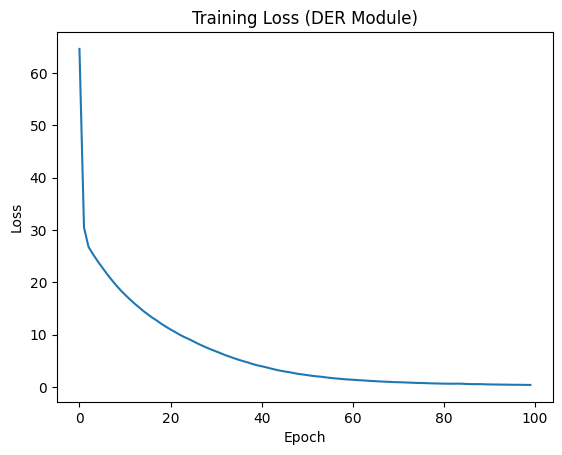

模型訓練完成！


In [ ]:
import matplotlib.pyplot as plt

# 1. 設定參數
num_epochs = 100  # 論文設定
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # 學習率可以試著調小一點點 (e.g., 0.0005) 如果震盪太大
loss_history = []

print(f"開始訓練 {num_epochs} 個 Epochs...")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in dataloader:
        tokens, pos, labels, mask = [b.to(device) for b in batch]

        optimizer.zero_grad()

        # 計算 Loss (Batch 總和)
        batch_loss = model(tokens, pos, labels, mask)

        # Backward pass
        batch_loss.backward()
        optimizer.step()

        total_loss += batch_loss.item()

    # 計算「平均每筆資料」的 Loss，以便跟論文比較
    # len(dataloader) 是 batch 的數量，所以這裡我們算的是平均每個 batch 的 loss
    # 若要精確，可以再除以 batch_size
    # avg_batch_loss = total_loss / len(dataloader)
    avg_sentence_loss = (total_loss / len(dataloader)) / 32  # 假設 batch_size=32

    # 紀錄
    loss_history.append(avg_sentence_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_sentence_loss:.4f}")

# 2. 繪製 Loss 曲線 (就像論文 Fig 2)
plt.plot(loss_history)
plt.title("Training Loss (DER Module)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 3. 儲存模型
torch.save(model.state_dict(), '/content/drive/MyDrive/DECEN/der_module_v2_100epochs.pth')
print("模型訓練完成！")

In [ ]:
import torch
import random

# 設定為評估模式
model.eval()

# 建立反查表 (ID -> 文字)
idx2word = {v: k for k, v in word2idx.items()}
idx2tag = {v: k for k, v in tag2idx.items()}

def evaluate_random_samples(model, dataset, num_samples=3):
    print(f"============== 模型預測檢查 (隨機 {num_samples} 筆) ==============")

    # 從資料集中隨機選取索引
    indices = random.sample(range(len(dataset)), num_samples)

    for i in indices:
        # 取出資料 (Tensor)
        tokens_tensor, pos_tensor, labels_tensor = dataset[i]

        # 增加 Batch 維度 (因為模型預期輸入是 Batch)
        tokens_in = tokens_tensor.unsqueeze(0).to(device)
        pos_in = pos_tensor.unsqueeze(0).to(device)
        mask = (tokens_in != 0).byte()

        # 進行預測
        with torch.no_grad():
            predicted_path = model(tokens_in, pos_in, mask=mask)
            predicted_tags = [idx2tag[t] for t in predicted_path[0]]

        # 還原原始文字與標籤
        original_tokens = [idx2word[t.item()] for t in tokens_tensor]
        original_labels = [idx2tag[l.item()] for l in labels_tensor]

        # 顯示結果
        print(f"\n【樣本 ID: {dataset.data[i]['post_id']}】")

        # 格式化輸出對齊
        print(f"{'詞彙':<8} | {'真實標籤':<10} | {'預測標籤':<10}")
        print("-" * 35)
        for w, true_l, pred_l in zip(original_tokens, original_labels, predicted_tags):
            # 只顯示有意義的詞，忽略 padding
            if w != '<PAD>':
                status = "✅" if true_l == pred_l else "❌"
                print(f"{w:<10} | {true_l:<10} | {pred_l:<10} {status}")

    print("\n========================================================")

# 執行檢查
evaluate_random_samples(model, dataset, num_samples=3)

============== 模型預測檢查 (隨機 3 筆) ==============

【樣本 ID: 903】
詞彙       | 真實標籤       | 預測標籤      
-----------------------------------
我          | O          | O          ✅
什麼         | O          | O          ✅
時候         | O          | O          ✅
才          | O          | O          ✅
會          | O          | O          ✅
知道         | O          | O          ✅
自己         | O          | O          ✅
需要         | O          | O          ✅
幫助         | O          | O          ✅
？          | O          | O          ✅
是          | O          | O          ✅
當          | O          | O          ✅
我          | O          | O          ✅
總是         | O          | O          ✅
被          | O          | O          ✅
自我         | O          | O          ✅
評價         | O          | O          ✅
的          | O          | O          ✅
陰影         | S-W        | S-W        ✅
<UNK>      | O          | O          ✅
？          | O          | O          ✅
還是         | O          | O          ✅
當          

In [ ]:
!pip install seqeval

In [ ]:
from seqeval.metrics import classification_report, f1_score, accuracy_score

def evaluate_metrics(model, dataloader):
    model.eval()

    # 儲存所有的預測與真實標籤 (必須是 List of List 格式)
    true_labels_list = []
    pred_labels_list = []

    idx2tag = {v: k for k, v in tag2idx.items()}

    with torch.no_grad():
        for batch in dataloader:
            tokens, pos, labels, mask = [b.to(device) for b in batch]

            # 取得最佳路徑
            pred_tags_ids = model(tokens, pos, mask=mask)

            # 將 Batch 裡的每一句解碼
            for i, pred_seq in enumerate(pred_tags_ids):
                # 取得該句真實長度 (過濾掉 PAD)
                # mask[i] 為 1 的地方才是真資料
                valid_len = mask[i].sum().item()

                # 真實標籤 (只取有效長度)
                true_seq_ids = labels[i][:valid_len].tolist()
                true_seq_str = [idx2tag[ID] for ID in true_seq_ids]

                # 預測標籤 (seqeval 對齊長度)
                # CRF decode 出來的長度通常已經是有效長度，但保險起見對齊一下
                pred_seq_str = [idx2tag[ID] for ID in pred_seq]

                true_labels_list.append(true_seq_str)
                pred_labels_list.append(pred_seq_str)

    # --- 輸出報告 ---
    print("\n【實體層級評估報告 (Entity-level Report)】")
    # seqeval 會自動處理 BMES/BIO 格式，算出每個情緒類別的 F1
    print(classification_report(true_labels_list, pred_labels_list, digits=4))

    f1 = f1_score(true_labels_list, pred_labels_list)
    print(f"整體 F1-Score: {f1:.4f}")

    return f1

# 執行評估 (建議丟入驗證集，這裡先用訓練集示範)
evaluate_metrics(model, dataloader)


【實體層級評估報告 (Entity-level Report)】


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-D seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-W seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-A seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-U seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: <PAD> seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWa

              precision    recall  f1-score   support

           A     0.0010    0.0847    0.0021       177
           D     0.0100    0.0951    0.0180      1304
        PAD>     0.0000    0.0000    0.0000         0
           U     0.0008    0.0265    0.0016       226
           W     0.0050    0.2226    0.0098       521

   micro avg     0.0043    0.1171    0.0084      2228
   macro avg     0.0034    0.0858    0.0063      2228
weighted avg     0.0072    0.1171    0.0132      2228

整體 F1-Score: 0.0084


np.float64(0.008357616318165808)

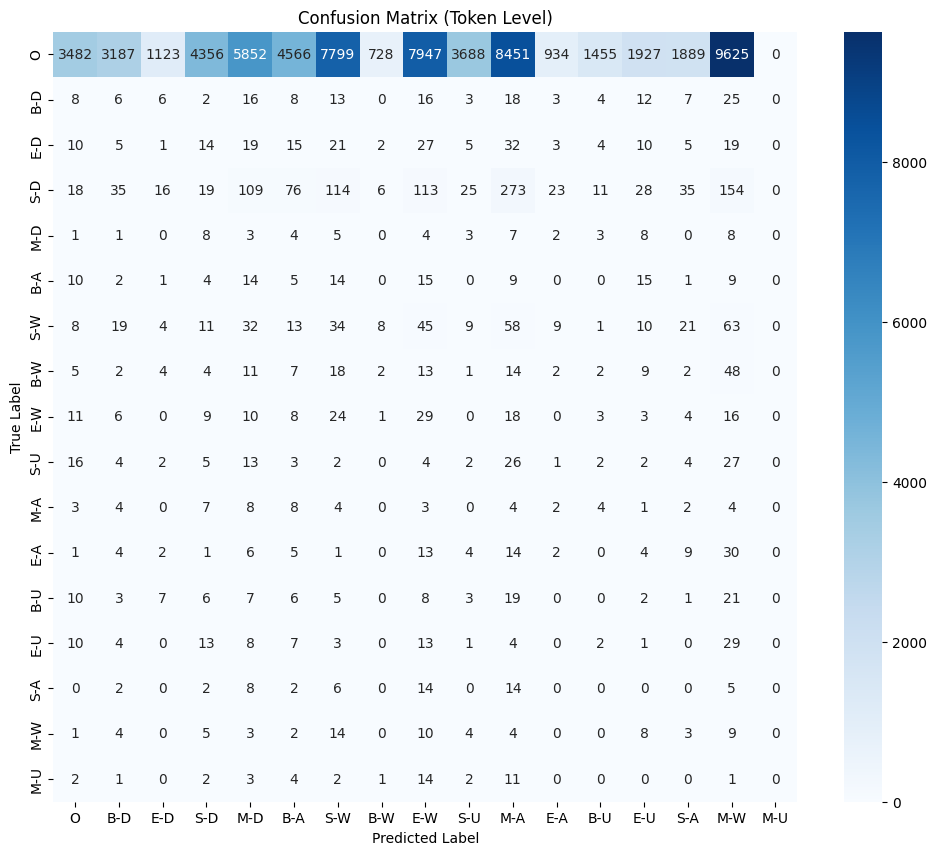

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_true = []
    all_pred = []

    idx2tag = {v: k for k, v in tag2idx.items()}

    with torch.no_grad():
        for batch in dataloader:
            tokens, pos, labels, mask = [b.to(device) for b in batch]
            pred_tags_ids = model(tokens, pos, mask=mask)

            for i, pred_seq in enumerate(pred_tags_ids):
                valid_len = mask[i].sum().item()
                true_seq_ids = labels[i][:valid_len].tolist()

                # 收集所有的 token (展平成一維)
                all_true.extend(true_seq_ids)
                all_pred.extend(pred_seq)

    # 轉換成文字標籤
    labels_list = list(tag2idx.keys())
    # 移除 <PAD> 和 <UNK> 不顯示
    labels_list = [l for l in labels_list if l not in ['<PAD>', '<UNK>']]

    # 計算混淆矩陣
    cm = confusion_matrix(
        [idx2tag[i] for i in all_true],
        [idx2tag[i] for i in all_pred],
        labels=labels_list
    )

    # 繪圖
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_list, yticklabels=labels_list, cmap='Blues')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix (Token Level)')
    plt.show()

# 執行繪圖
plot_confusion_matrix(model, dataloader)

In [ ]:
!pip -q install torchcrf==1.1.0 seqeval==1.2.2 jieba

In [ ]:
# ============================================
# DECEN DER (Paper-style) with auto POS tagging:
# word embedding + POS embedding -> concat -> BiLSTM -> CRF
# Data columns: post_id, caption, word, human_label, word order
# ============================================

!pip -q install torchcrf==1.1.0 seqeval==1.2.2 jieba

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchcrf import CRF
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
import random
from collections import Counter
import jieba.posseg as pseg

# -------------------------
# 0. Reproducibility
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -------------------------
# 1. Load CSV
# -------------------------
CSV_PATH = "/content/drive/MyDrive/select_de_synold_filtered.csv"
df = pd.read_csv(CSV_PATH)

# 你說的主要欄位
POST_COL = "post_id"
WORD_COL = "word"
LAB_COL  = "human_label"
ORDER_COL = "word_order"   # 若你的欄位名稱不同，改這行即可

required = [POST_COL, WORD_COL, LAB_COL, ORDER_COL]
for c in required:
    if c not in df.columns:
        raise ValueError(f"找不到欄位：{c}，目前欄位={df.columns.tolist()}")

print("df.shape:", df.shape)
print(df[[POST_COL, WORD_COL, LAB_COL, ORDER_COL]].head())

# -------------------------
# 2. Auto POS tagging (jieba.posseg)
# -------------------------
# 注意：你是「已斷詞後」的 word，所以這裡用「逐詞 POS」
# 優點：對齊你現有 token，不會斷詞不一致
# 缺點：少了上下文（但仍可作為論文版 POS embedding 的實作替代）
def get_pos_tag_for_word(w: str) -> str:
    w = str(w)
    if w.strip() == "":
        return "x"
    try:
        it = pseg.cut(w)
        first = next(it, None)
        if first is None:
            return "x"
        return first.flag if first.flag else "x"
    except Exception:
        return "x"

print("Building POS tags...")
df["pos"] = df[WORD_COL].astype(str).apply(get_pos_tag_for_word)
print(df[[WORD_COL, "pos"]].head(10))

# -------------------------
# 3. Sort by (post_id, word order) to form sequences
# -------------------------
df = df.sort_values([POST_COL, ORDER_COL]).reset_index(drop=True)

grouped = df.groupby(POST_COL, sort=False)

posts_words, posts_pos, posts_labels = [], [], []
post_ids = []

for pid, g in grouped:
    toks = g[WORD_COL].astype(str).tolist()
    poss = g["pos"].astype(str).tolist()
    labs = g[LAB_COL].astype(str).tolist()
    if len(toks) == 0:
        continue
    posts_words.append(toks)
    posts_pos.append(poss)
    posts_labels.append(labs)
    post_ids.append(pid)

print("num posts:", len(posts_words))
print("example tokens:", posts_words[0][:10])
print("example pos   :", posts_pos[0][:10])
print("example labels:", posts_labels[0][:10])

# -------------------------
# 4. Build vocab: word2id, pos2id, label2id
# -------------------------
PAD = "<PAD>"
UNK = "<UNK>"

word_counter = Counter([w for seq in posts_words for w in seq])
pos_counter  = Counter([p for seq in posts_pos for p in seq])
label_set    = sorted(list(set([y for seq in posts_labels for y in seq])))

word2id = {PAD:0, UNK:1}
for w, _ in word_counter.most_common():
    word2id[w] = len(word2id)

pos2id = {PAD:0, UNK:1}
for p, _ in pos_counter.most_common():
    pos2id[p] = len(pos2id)

label2id = {lab:i for i, lab in enumerate(label_set)}
id2label = {i:lab for lab, i in label2id.items()}

print("vocab size:", len(word2id), "pos size:", len(pos2id), "num labels:", len(label2id))
print("labels sample:", label_set[:30])

# -------------------------
# 5. Train/Val split by post (sequence)
# -------------------------
idx_all = list(range(len(posts_words)))
train_idx, val_idx = train_test_split(idx_all, test_size=0.2, random_state=42, shuffle=True)

def select(arr, idxs):
    return [arr[i] for i in idxs]

train_words  = select(posts_words, train_idx)
train_pos    = select(posts_pos, train_idx)
train_labels = select(posts_labels, train_idx)

val_words  = select(posts_words, val_idx)
val_pos    = select(posts_pos, val_idx)
val_labels = select(posts_labels, val_idx)

print("train posts:", len(train_words), "val posts:", len(val_words))

# -------------------------
# 6. Dataset + collate (pad)
# -------------------------
def encode_seq(seq, vocab):
    return [vocab.get(x, vocab[UNK]) for x in seq]

def encode_label(seq, vocab):
    # label 必須都在 label2id 內
    return [vocab[x] for x in seq]

class SequenceDataset(Dataset):
    def __init__(self, words_list, pos_list, labels_list):
        self.words_list = words_list
        self.pos_list = pos_list
        self.labels_list = labels_list

    def __len__(self):
        return len(self.words_list)

    def __getitem__(self, idx):
        w = encode_seq(self.words_list[idx], word2id)
        p = encode_seq(self.pos_list[idx], pos2id)
        y = encode_label(self.labels_list[idx], label2id)
        return {
            "word_ids": torch.tensor(w, dtype=torch.long),
            "pos_ids": torch.tensor(p, dtype=torch.long),
            "label_ids": torch.tensor(y, dtype=torch.long),
        }

def collate_fn(batch):
    max_len = max(x["word_ids"].size(0) for x in batch)
    bsz = len(batch)

    word_pad = torch.full((bsz, max_len), word2id[PAD], dtype=torch.long)
    pos_pad  = torch.full((bsz, max_len),  pos2id[PAD], dtype=torch.long)
    lab_pad  = torch.full((bsz, max_len), -1, dtype=torch.long)
    mask     = torch.zeros((bsz, max_len), dtype=torch.bool)

    for i, x in enumerate(batch):
        L = x["word_ids"].size(0)
        word_pad[i, :L] = x["word_ids"]
        pos_pad[i, :L]  = x["pos_ids"]
        lab_pad[i, :L]  = x["label_ids"]
        mask[i, :L]     = True

    return {"word_ids": word_pad, "pos_ids": pos_pad, "label_ids": lab_pad, "mask": mask}

train_loader = DataLoader(SequenceDataset(train_words, train_pos, train_labels),
                          batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(SequenceDataset(val_words, val_pos, val_labels),
                          batch_size=16, shuffle=False, collate_fn=collate_fn)

# -------------------------
# 7. Model: WordEmb + POSEmb -> concat -> BiLSTM -> Linear -> CRF
# -------------------------
class BiLSTM_CRF(nn.Module):
    def __init__(self, word_vocab_size, pos_vocab_size, num_labels,
                 word_dim=200, pos_dim=50, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.word_emb = nn.Embedding(word_vocab_size, word_dim, padding_idx=word2id[PAD])
        self.pos_emb  = nn.Embedding(pos_vocab_size,  pos_dim,  padding_idx=pos2id[PAD])

        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=word_dim + pos_dim,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim, num_labels)
        self.crf = CRF(num_labels, batch_first=True)

    def forward(self, word_ids, pos_ids, mask, labels=None):
        w = self.word_emb(word_ids)
        p = self.pos_emb(pos_ids)
        x = torch.cat([w, p], dim=-1)  # concat word+POS
        x = self.dropout(x)

        feats, _ = self.lstm(x)
        feats = self.dropout(feats)
        emissions = self.fc(feats)

        if labels is not None:
            loss = -self.crf(emissions, labels, mask=mask, reduction='mean')
            return loss
        else:
            pred = self.crf.decode(emissions, mask=mask)
            return pred

model = BiLSTM_CRF(
    word_vocab_size=len(word2id),
    pos_vocab_size=len(pos2id),
    num_labels=len(label2id),
    word_dim=200,     # 可改 300
    pos_dim=50,
    hidden_dim=256,
    dropout=0.2
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)

# -------------------------
# 8. Train / Eval
# -------------------------
def ids_to_labels(batch_preds, batch_true, mask):
    y_true, y_pred = [], []
    for i, pred_seq in enumerate(batch_preds):
        true_seq = batch_true[i][mask[i]].tolist()
        y_true.append([id2label[t] for t in true_seq])
        y_pred.append([id2label[p] for p in pred_seq])
    return y_true, y_pred

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_true, all_pred = [], []
    total_loss, n_batches = 0.0, 0

    for batch in loader:
        word_ids = batch["word_ids"].to(device)
        pos_ids  = batch["pos_ids"].to(device)
        labels   = batch["label_ids"].to(device)
        mask     = batch["mask"].to(device)

        loss = model(word_ids, pos_ids, mask, labels=labels)
        preds = model(word_ids, pos_ids, mask, labels=None)

        yt, yp = ids_to_labels(preds, labels, mask)
        all_true.extend(yt)
        all_pred.extend(yp)

        total_loss += loss.item()
        n_batches += 1

    f1 = f1_score(all_true, all_pred)
    p  = precision_score(all_true, all_pred)
    r  = recall_score(all_true, all_pred)
    return total_loss / max(n_batches, 1), p, r, f1, all_true, all_pred

def train_one_epoch(model, loader):
    model.train()
    total_loss, n_batches = 0.0, 0

    for batch in loader:
        word_ids = batch["word_ids"].to(device)
        pos_ids  = batch["pos_ids"].to(device)
        labels   = batch["label_ids"].to(device)
        mask     = batch["mask"].to(device)

        loss = model(word_ids, pos_ids, mask, labels=labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)




device: cuda


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.cache


df.shape: (73371, 12)
   post_id word human_label  word_order
0        3   心情           O         1.0
1        3   情緒           O         2.0
2        3   部份           O         3.0
3        3   一直           O         4.0
4        3   覺得           O         5.0
Building POS tags...


Loading model cost 1.974 seconds.
DEBUG:jieba:Loading model cost 1.974 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


  word pos
0   心情   n
1   情緒   n
2   部份   n
3   一直   d
4   覺得   v
5   哪裡   r
6  怪怪的   z
7    （   x
8    ？   x
9    ）   x
num posts: 664
example tokens: ['心情', '情緒', '部份', '一直', '覺得', '哪裡', '怪怪的', '（', '？', '）']
example pos   : ['n', 'n', 'n', 'd', 'v', 'r', 'z', 'x', 'x', 'x']
example labels: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
vocab size: 7967 pos size: 53 num labels: 17
labels sample: ['B-A', 'B-D', 'B-U', 'B-W', 'E-A', 'E-D', 'E-U', 'E-W', 'M-A', 'M-D', 'M-U', 'M-W', 'O', 'S-A', 'S-D', 'S-U', 'S-W']
train posts: 531 val posts: 133


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-A seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-U seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-W seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-D seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(r

[Epoch 01] TrainLoss=76.1589 | ValLoss=24.3904 | P=0.0000 R=0.0000 F1=0.0000
[Epoch 02] TrainLoss=23.1385 | ValLoss=18.8963 | P=0.7662 R=0.1460 F1=0.2453
[Epoch 03] TrainLoss=17.0266 | ValLoss=16.9029 | P=0.7417 R=0.2203 F1=0.3397
[Epoch 04] TrainLoss=13.9379 | ValLoss=16.0377 | P=0.6839 R=0.2624 F1=0.3792
[Epoch 05] TrainLoss=11.5846 | ValLoss=14.4977 | P=0.5719 R=0.3936 F1=0.4663
[Epoch 06] TrainLoss=9.6541 | ValLoss=14.3681 | P=0.6050 R=0.3564 F1=0.4486
[Epoch 07] TrainLoss=7.9137 | ValLoss=14.7397 | P=0.5903 R=0.4208 F1=0.4913
[Epoch 08] TrainLoss=6.4584 | ValLoss=14.9814 | P=0.6624 R=0.3886 F1=0.4899
[Epoch 09] TrainLoss=5.3790 | ValLoss=14.2382 | P=0.5828 R=0.4530 F1=0.5097
[Epoch 10] TrainLoss=4.2180 | ValLoss=15.1344 | P=0.6267 R=0.4530 F1=0.5259
[Epoch 11] TrainLoss=3.4590 | ValLoss=15.7828 | P=0.6374 R=0.4134 F1=0.5015
[Epoch 12] TrainLoss=3.0228 | ValLoss=16.6093 | P=0.6815 R=0.4183 F1=0.5184
[Epoch 13] TrainLoss=2.3512 | ValLoss=17.0543 | P=0.6353 R=0.4183 F1=0.5045
[Epoch 

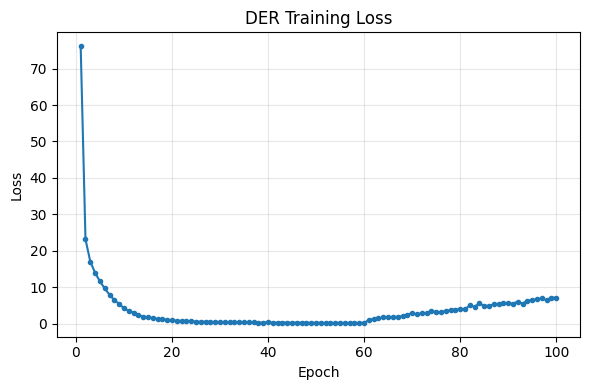

In [ ]:
EPOCHS = 100
best_f1 = -1
train_loss_history = []
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    train_loss_history.append(tr_loss)

    va_loss, p, r, f1, yt, yp = evaluate(model, val_loader)
    print(f"[Epoch {epoch:02d}] TrainLoss={tr_loss:.4f} | ValLoss={va_loss:.4f} | P={p:.4f} R={r:.4f} F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save({
            "model_state": model.state_dict(),
            "word2id": word2id,
            "pos2id": pos2id,
            "label2id": label2id,
            "id2label": id2label
        }, "/content/drive/MyDrive/DECEN/best_der_bilstm_crf_with_jieba_pos_100.pt")

print("\nBest F1:", best_f1)
print("\nClassification report (val):")
print(classification_report(yt, yp, digits=4))

import matplotlib.pyplot as plt

epochs = list(range(1, len(train_loss_history) + 1))

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_history, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DER Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


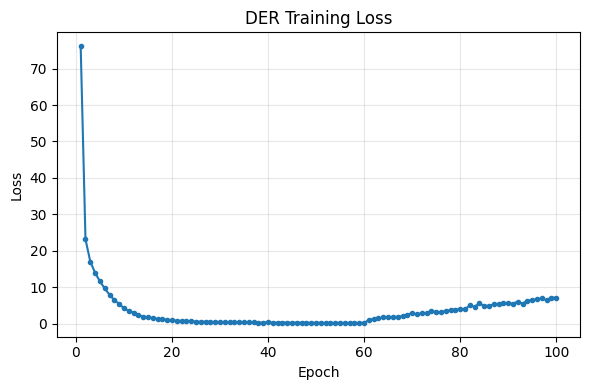

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_loss_history) + 1))

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_history, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DER Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
EPOCHS = 100
best_f1 = -1
best_epoch = -1

patience = 10     # 連續 10 個 epoch 沒進步就停（可調 5/10/15）
min_delta = 1e-4  # 最小提升幅度，小於這個不算進步
no_improve = 0

train_loss_history = []
val_loss_history = []
val_f1_history = []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    train_loss_history.append(tr_loss)

    va_loss, p, r, f1, yt, yp = evaluate(model, val_loader)
    val_loss_history.append(va_loss)
    val_f1_history.append(f1)

    print(f"[Epoch {epoch:02d}] TrainLoss={tr_loss:.4f} | ValLoss={va_loss:.4f} | P={p:.4f} R={r:.4f} F1={f1:.4f}")

    # ---- F1 early stopping logic ----
    if f1 > best_f1 + min_delta:
        best_f1 = f1
        best_epoch = epoch
        no_improve = 0

        torch.save({
            "model_state": model.state_dict(),
            "word2id": word2id,
            "pos2id": pos2id,
            "label2id": label2id,
            "id2label": id2label,
            "best_epoch": best_epoch,
            "best_f1": best_f1
        }, "/content/drive/MyDrive/DECEN/best_der_bilstm_crf_with_jieba_pos.pt")

        print(f"  ✅ New best F1={best_f1:.4f} at epoch {best_epoch}, model saved.")
    else:
        no_improve += 1
        print(f"  ⏳ No improvement: {no_improve}/{patience}")

        if no_improve >= patience:
            print(f"\n🛑 Early stopping triggered. Best F1={best_f1:.4f} at epoch {best_epoch}.")
            break

print("\nBest F1:", best_f1, "Best epoch:", best_epoch)
print("\nClassification report (last evaluated epoch):")
print(classification_report(yt, yp, digits=4))


[Epoch 01] TrainLoss=23.1385 | ValLoss=18.8963 | P=0.7662 R=0.1460 F1=0.2453
  ✅ New best F1=0.2453 at epoch 1, model saved.
[Epoch 02] TrainLoss=17.0266 | ValLoss=16.9029 | P=0.7417 R=0.2203 F1=0.3397
  ✅ New best F1=0.3397 at epoch 2, model saved.
[Epoch 03] TrainLoss=13.9379 | ValLoss=16.0377 | P=0.6839 R=0.2624 F1=0.3792
  ✅ New best F1=0.3792 at epoch 3, model saved.
[Epoch 04] TrainLoss=11.5846 | ValLoss=14.4977 | P=0.5719 R=0.3936 F1=0.4663
  ✅ New best F1=0.4663 at epoch 4, model saved.
[Epoch 05] TrainLoss=9.6541 | ValLoss=14.3681 | P=0.6050 R=0.3564 F1=0.4486
  ⏳ No improvement: 1/10
[Epoch 06] TrainLoss=7.9137 | ValLoss=14.7397 | P=0.5903 R=0.4208 F1=0.4913
  ✅ New best F1=0.4913 at epoch 6, model saved.
[Epoch 07] TrainLoss=6.4584 | ValLoss=14.9814 | P=0.6624 R=0.3886 F1=0.4899
  ⏳ No improvement: 1/10
[Epoch 08] TrainLoss=5.3790 | ValLoss=14.2382 | P=0.5828 R=0.4530 F1=0.5097
  ✅ New best F1=0.5097 at epoch 8, model saved.
[Epoch 09] TrainLoss=4.2180 | ValLoss=15.1344 | P=

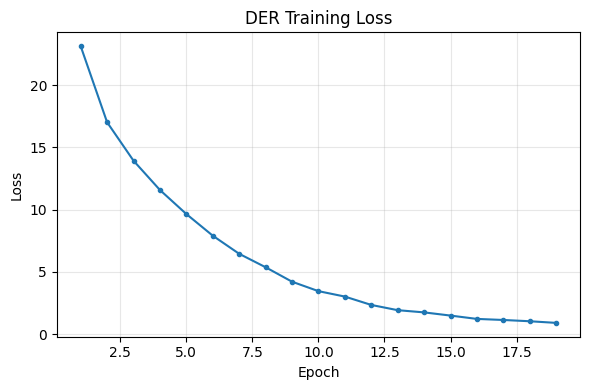

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_loss_history) + 1))

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_history, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DER Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
from collections import Counter

all_pred_labels = []
for seq in yp:          # yp 是 seqeval 用的 entity label
    all_pred_labels.extend(seq)

Counter(all_pred_labels)


Counter({'O': 11459,
         'S-D': 123,
         'S-W': 54,
         'B-D': 18,
         'E-D': 18,
         'B-A': 12,
         'M-A': 1,
         'E-A': 11,
         'B-U': 14,
         'M-U': 5,
         'E-U': 15,
         'B-W': 15,
         'M-W': 5,
         'E-W': 15,
         'S-U': 10,
         'M-D': 4,
         'S-A': 1})

Total entity tokens (excluding 'O'): 547
Sample true labels: ['B-A', 'M-A', 'E-A', 'S-D', 'S-D', 'S-W', 'S-W', 'S-U', 'S-D', 'S-D']
Sample pred labels: ['O', 'O', 'S-D', 'O', 'S-D', 'O', 'S-W', 'O', 'O', 'O']
Labels in confusion matrix: ['B-A', 'B-D', 'B-U', 'B-W', 'E-A', 'E-D', 'E-U', 'E-W', 'M-A', 'M-D', 'M-U', 'M-W', 'O', 'S-A', 'S-D', 'S-U', 'S-W']
Confusion matrix shape: (17, 17)


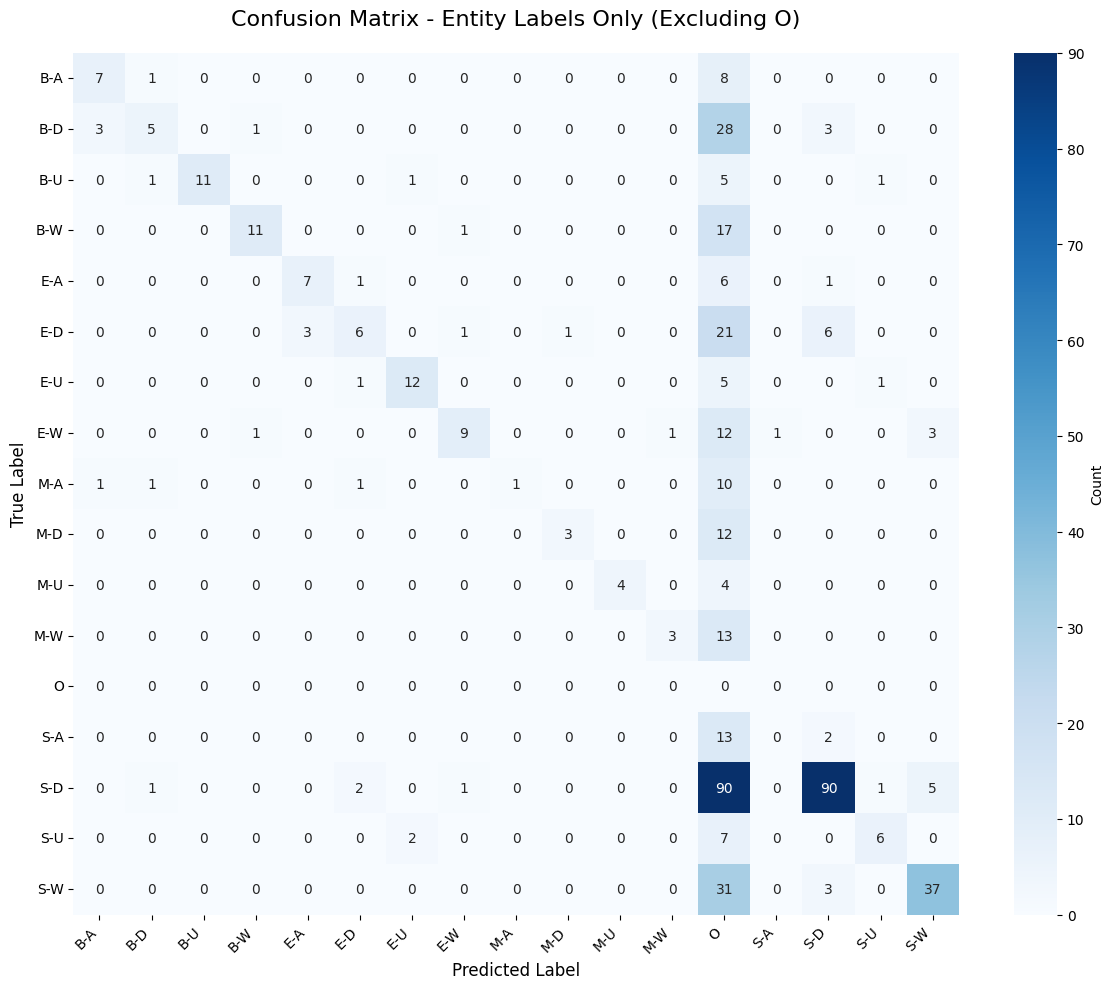

/tmp/ipython-input-1879536444.py:45: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


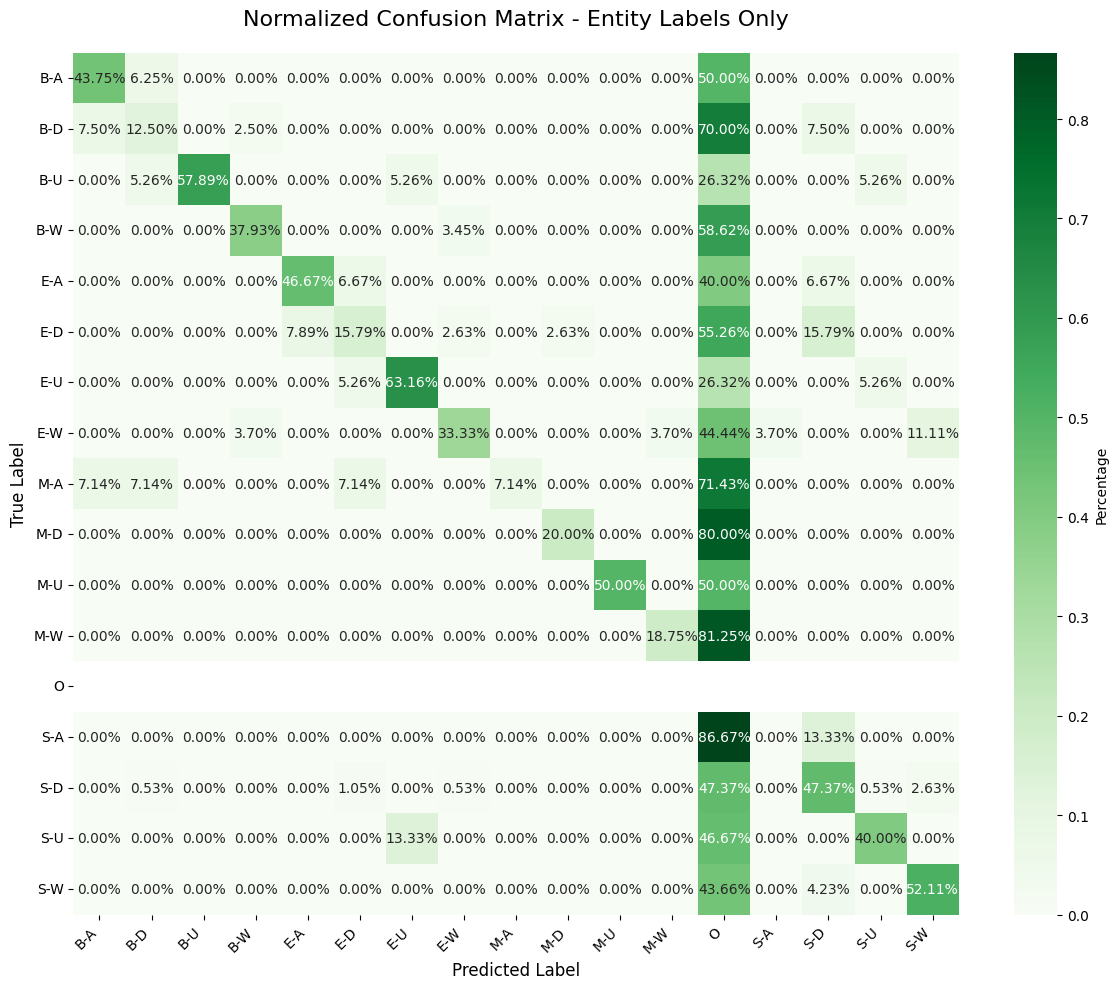


📊 Confusion Matrix Analysis (Entity Labels Only):
B-A            :     7/   16 = 43.75%
B-D            :     5/   40 = 12.50%
B-U            :    11/   19 = 57.89%
B-W            :    11/   29 = 37.93%
E-A            :     7/   15 = 46.67%
E-D            :     6/   38 = 15.79%
E-U            :    12/   19 = 63.16%
E-W            :     9/   27 = 33.33%
M-A            :     1/   14 = 7.14%
M-D            :     3/   15 = 20.00%
M-U            :     4/    8 = 50.00%
M-W            :     3/   16 = 18.75%
O              :     0/    0 = 0.00%
S-A            :     0/   15 = 0.00%
S-D            :    90/  190 = 47.37%
S-U            :     6/   15 = 40.00%
S-W            :    37/   71 = 52.11%

🔍 Most Confused Label Pairs:
S-D        → O         :   90 times
S-W        → O         :   31 times
B-D        → O         :   28 times
E-D        → O         :   21 times
B-W        → O         :   17 times
M-W        → O         :   13 times
S-A        → O         :   13 times
E-W        → O         :

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. 將nested lists展平並過濾掉 'O' 標籤
yt_flat_filtered = []
yp_flat_filtered = []

for yt_sent, yp_sent in zip(yt, yp):
    for true_label, pred_label in zip(yt_sent, yp_sent):
        if true_label != 'O':  # 只保留非O標籤
            yt_flat_filtered.append(true_label)
            yp_flat_filtered.append(pred_label)

print(f"Total entity tokens (excluding 'O'): {len(yt_flat_filtered)}")
print(f"Sample true labels: {yt_flat_filtered[:10]}")
print(f"Sample pred labels: {yp_flat_filtered[:10]}")

# 2. 計算混淆矩陣
cm = confusion_matrix(yt_flat_filtered, yp_flat_filtered)

# 3. 取得所有出現過的標籤名稱(已經是字串,不需要轉換)
unique_labels = sorted(set(yt_flat_filtered) | set(yp_flat_filtered))
labels = unique_labels

print(f"Labels in confusion matrix: {labels}")
print(f"Confusion matrix shape: {cm.shape}")

# 4. 繪製混淆矩陣
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})

plt.title('Confusion Matrix - Entity Labels Only (Excluding O)', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. 顯示歸一化的混淆矩陣(百分比)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Percentage'})

plt.title('Normalized Confusion Matrix - Entity Labels Only', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. 印出詳細統計
print("\n📊 Confusion Matrix Analysis (Entity Labels Only):")
print("=" * 60)
for i, label in enumerate(labels):
    total = cm[i].sum()
    correct = cm[i, i]
    acc = correct / total if total > 0 else 0
    print(f"{label:15s}: {correct:5d}/{total:5d} = {acc:.2%}")

# 7. 找出最容易混淆的標籤對
print("\n🔍 Most Confused Label Pairs:")
print("=" * 60)
confused_pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((labels[i], labels[j], cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_lab, pred_lab, count in confused_pairs[:10]:
    print(f"{true_lab:10s} → {pred_lab:10s}: {count:4d} times")

Total entity tokens (main categories only): 547
Sample true categories: ['A', 'A', 'A', 'D', 'D', 'W', 'W', 'U', 'D', 'D', 'D', 'A', 'A', 'A', 'A', 'A', 'D', 'W', 'W', 'U']
Sample pred categories: ['O', 'O', 'D', 'O', 'D', 'O', 'W', 'O', 'O', 'O', 'O', 'O', 'O', 'A', 'A', 'A', 'O', 'O', 'O', 'U']

Main categories: ['A', 'D', 'O', 'U', 'W']
Confusion matrix shape: (5, 5)


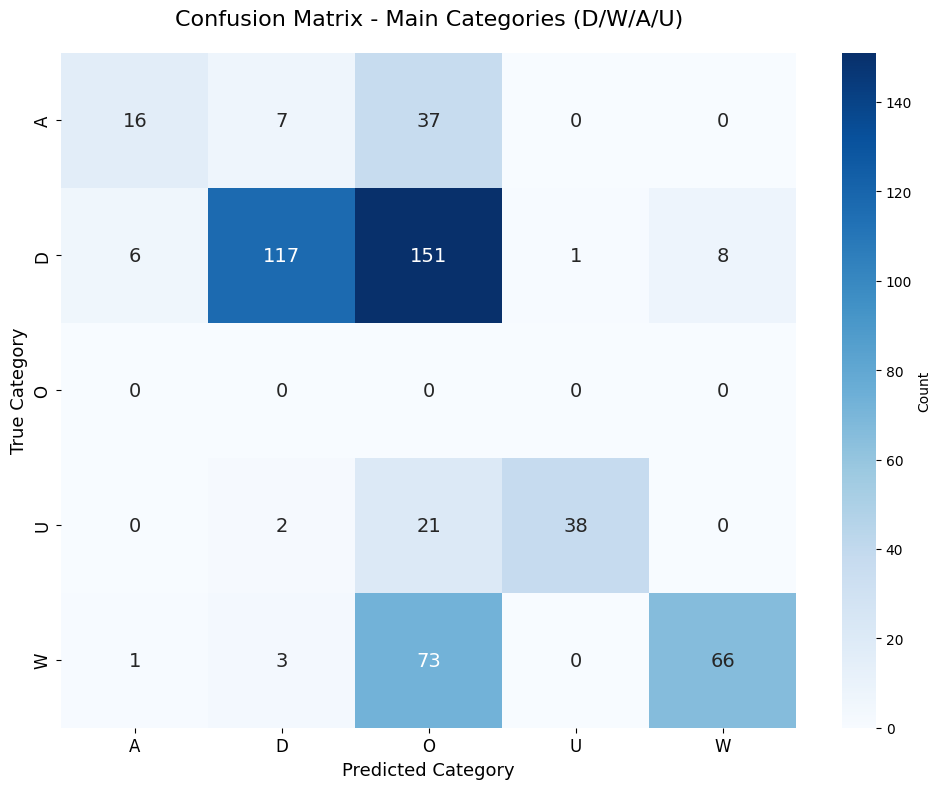

/tmp/ipython-input-3791846445.py:64: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


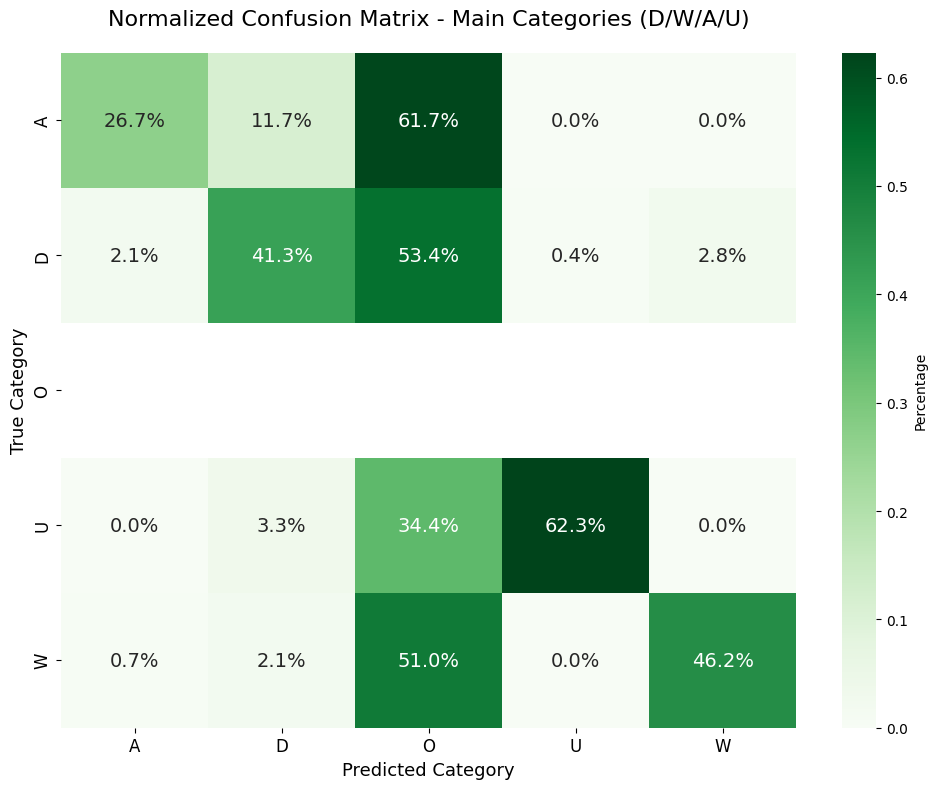


📊 Confusion Matrix Analysis (Main Categories):
A         :    16/   60 = 26.67%
D         :   117/  283 = 41.34%
O         :     0/    0 = 0.00%
U         :    38/   61 = 62.30%
W         :    66/  143 = 46.15%

🔍 Most Confused Category Pairs:
D     → O    :  151 times
W     → O    :   73 times
A     → O    :   37 times
U     → O    :   21 times
D     → W    :    8 times
A     → D    :    7 times
D     → A    :    6 times
W     → D    :    3 times
U     → D    :    2 times
D     → U    :    1 times
W     → A    :    1 times

📈 Classification Report (Main Categories):
              precision    recall  f1-score   support

           A     0.6957    0.2667    0.3855        60
           D     0.9070    0.4134    0.5680       283
           O     0.0000    0.0000    0.0000         0
           U     0.9744    0.6230    0.7600        61
           W     0.8919    0.4615    0.6083       143

    accuracy                         0.4333       547
   macro avg     0.6938    0.3529    0.4644  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. 定義函數:將 BIO 標籤轉換為主類別
def extract_main_category(label):
    """
    B-A, M-A, E-A, S-A -> A
    B-D, M-D, E-D, S-D -> D
    O -> O
    """
    if label == 'O':
        return 'O'
    # 取最後一個字元作為主類別 (B-A -> A, S-D -> D)
    parts = label.split('-')
    if len(parts) == 2:
        return parts[1]  # 取 '-' 後面的部分
    return label  # 防止異常格式

# 2. 將 yt 和 yp 轉換為主類別並展平
yt_main_flat = []
yp_main_flat = []

for yt_sent, yp_sent in zip(yt, yp):
    for true_label, pred_label in zip(yt_sent, yp_sent):
        true_main = extract_main_category(true_label)
        pred_main = extract_main_category(pred_label)

        # 只保留非O的標籤
        if true_main != 'O':
            yt_main_flat.append(true_main)
            yp_main_flat.append(pred_main)

print(f"Total entity tokens (main categories only): {len(yt_main_flat)}")
print(f"Sample true categories: {yt_main_flat[:20]}")
print(f"Sample pred categories: {yp_main_flat[:20]}")

# 3. 計算混淆矩陣
cm = confusion_matrix(yt_main_flat, yp_main_flat)

# 4. 取得類別標籤
unique_labels = sorted(set(yt_main_flat) | set(yp_main_flat))
labels = unique_labels

print(f"\nMain categories: {labels}")
print(f"Confusion matrix shape: {cm.shape}")

# 5. 繪製混淆矩陣
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})

plt.title('Confusion Matrix - Main Categories (D/W/A/U)', fontsize=16, pad=20)
plt.xlabel('Predicted Category', fontsize=13)
plt.ylabel('True Category', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 6. 顯示歸一化的混淆矩陣(百分比)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Percentage'}, annot_kws={'size': 14})

plt.title('Normalized Confusion Matrix - Main Categories (D/W/A/U)', fontsize=16, pad=20)
plt.xlabel('Predicted Category', fontsize=13)
plt.ylabel('True Category', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 7. 印出詳細統計
print("\n📊 Confusion Matrix Analysis (Main Categories):")
print("=" * 60)
for i, label in enumerate(labels):
    total = cm[i].sum()
    correct = cm[i, i]
    acc = correct / total if total > 0 else 0
    print(f"{label:10s}: {correct:5d}/{total:5d} = {acc:.2%}")

# 8. 找出最容易混淆的類別對
print("\n🔍 Most Confused Category Pairs:")
print("=" * 60)
confused_pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((labels[i], labels[j], cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_cat, pred_cat, count in confused_pairs:
    print(f"{true_cat:5s} → {pred_cat:5s}: {count:4d} times")

# 9. 計算整體的 Precision, Recall, F1
print("\n📈 Classification Report (Main Categories):")
print("=" * 60)
print(classification_report(yt_main_flat, yp_main_flat, digits=4))

In [ ]:
# ============================================
# Pipeline B (No BMES): Sentence-level DER' + Focal Loss
# Data: post_id, caption, word, human_label, word order
# Steps:
# 1) Build sentences from caption
# 2) Map tokens (word order) to sentence by char span
# 3) Derive sentence label from token BMES labels
# 4) Train BERT classifier with Focal Loss
# ============================================

!pip -q install transformers==4.44.2 accelerate==0.33.0 jieba

import re
import os
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

# -------------------------
# 0. Reproducibility
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -------------------------
# 1. Load CSV
# -------------------------
CSV_PATH = "/content/drive/MyDrive/select_de_synold_filtered.csv"
df = pd.read_csv(CSV_PATH)

POST_COL  = "post_id"
CAP_COL   = "caption"
WORD_COL  = "word"
LAB_COL   = "human_label"
ORDER_COL = "word_order"

for c in [POST_COL, CAP_COL, WORD_COL, LAB_COL, ORDER_COL]:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}. Current columns={df.columns.tolist()}")

df = df.copy()
df[CAP_COL] = df[CAP_COL].fillna("").astype(str)
df[WORD_COL] = df[WORD_COL].fillna("").astype(str)
df[LAB_COL] = df[LAB_COL].fillna("O").astype(str)

# sort tokens within each post
df = df.sort_values([POST_COL, ORDER_COL]).reset_index(drop=True)
print("df.shape:", df.shape)
print(df[[POST_COL, CAP_COL, WORD_COL, LAB_COL, ORDER_COL]].head())

# -------------------------
# 2. Utilities: sentence splitting + token span mapping
# -------------------------
SENT_SPLIT_RE = re.compile(r'([。！？!?\n]+)')

def split_sentences_with_spans(text: str):
    """
    Split text into sentences and return [(sent, start_idx, end_idx), ...]
    Keep punctuation at sentence end.
    """
    text = text.strip()
    if not text:
        return []

    parts = SENT_SPLIT_RE.split(text)
    sents = []
    cursor = 0
    buf = ""
    start = 0

    for part in parts:
        if part == "":
            continue
        buf += part
        # if part is punctuation group, finalize a sentence
        if SENT_SPLIT_RE.fullmatch(part):
            end = start + len(buf)
            sents.append((buf, start, end))
            start = end
            buf = ""

    # leftover without ending punctuation
    if buf.strip():
        end = start + len(buf)
        sents.append((buf, start, end))

    # remove empty
    sents = [(s, a, b) for (s, a, b) in sents if s.strip()]
    return sents

def build_token_char_spans_from_words(caption: str, words: list):
    """
    Given a caption and its token list (in order),
    try to find each token in caption sequentially to get char spans.
    Returns list of (start, end) for each token, or (-1,-1) if fail.
    This assumes your tokens come from segmenting caption in order.
    """
    spans = []
    pos = 0
    for w in words:
        w = str(w)
        if w == "":
            spans.append((-1, -1))
            continue
        idx = caption.find(w, pos)
        if idx == -1:
            # fallback: try from earlier (rare)
            idx = caption.find(w)
            if idx == -1:
                spans.append((-1, -1))
                continue
        start = idx
        end = idx + len(w)
        spans.append((start, end))
        pos = end
    return spans

def span_to_sentence_id(token_span, sentence_spans):
    """
    token_span: (s,e)
    sentence_spans: [(sent, s0, e0), ...]
    return sentence index if overlap, else None
    """
    s, e = token_span
    if s < 0 or e < 0:
        return None
    # choose the sentence with maximal overlap
    best_i, best_overlap = None, 0
    for i, (_, ss, ee) in enumerate(sentence_spans):
        overlap = max(0, min(e, ee) - max(s, ss))
        if overlap > best_overlap:
            best_overlap = overlap
            best_i = i
    return best_i if best_overlap > 0 else None

# -------------------------
# 3. Convert BMES labels to emotion (D/A/W/U/O)
# -------------------------
PRIORITY = ["U", "A", "W", "D", "O"]  # you can adjust if needed

def bmes_to_emotion(lab: str):
    lab = str(lab)
    if lab == "O":
        return "O"
    # e.g., B-D, M-W, E-U, S-A
    if "-" in lab:
        return lab.split("-")[-1]
    # if your label is just D/A/W/U
    if lab in ["D","W","A","U"]:
        return lab
    return "O"

def aggregate_sentence_label(bmes_labels: list):
    emos = [bmes_to_emotion(x) for x in bmes_labels]
    for p in PRIORITY:
        if p in emos:
            return p
    return "O"

label2id = {"O":0, "D":1, "W":2, "A":3, "U":4}
id2label = {v:k for k,v in label2id.items()}

# -------------------------
# 4. Build sentence-level dataset from posts
# -------------------------
rows = []

for pid, g in df.groupby(POST_COL, sort=False):
    caption = g[CAP_COL].iloc[0]
    words = g[WORD_COL].tolist()
    bmes  = g[LAB_COL].tolist()

    sentence_spans = split_sentences_with_spans(caption)

    # If caption can't be split (empty), treat whole caption as one segment
    if len(sentence_spans) == 0:
        sentence_spans = [(caption, 0, len(caption))] if caption.strip() else []

    token_spans = build_token_char_spans_from_words(caption, words)

    # group token indices by sentence id
    sent2token_idx = {i: [] for i in range(len(sentence_spans))}
    for ti, sp in enumerate(token_spans):
        sid = span_to_sentence_id(sp, sentence_spans)
        if sid is not None:
            sent2token_idx[sid].append(ti)

    # Create sentence samples
    for sid, (sent_text, ss, ee) in enumerate(sentence_spans):
        token_idxs = sent2token_idx.get(sid, [])
        if len(token_idxs) == 0:
            # no aligned tokens; still keep as O (or drop)
            sent_label = "O"
        else:
            sent_label = aggregate_sentence_label([bmes[i] for i in token_idxs])

        rows.append({
            "post_id": pid,
            "sentence_id": sid,
            "text": sent_text.strip(),
            "label": sent_label,
            "label_id": label2id[sent_label]
        })

sent_df = pd.DataFrame(rows)
# remove empty sentences
sent_df = sent_df[sent_df["text"].astype(str).str.len() > 0].reset_index(drop=True)

print("Sentence-level samples:", sent_df.shape)
print(sent_df["label"].value_counts())

# Optional: remove all-O sentences if you want focus only on emotional sentences
# sent_df = sent_df[sent_df["label"] != "O"].reset_index(drop=True)

# -------------------------
# 5. Train/Val split (by post_id to avoid leakage)
# -------------------------
unique_posts = sent_df["post_id"].unique().tolist()
train_posts, val_posts = train_test_split(unique_posts, test_size=0.2, random_state=42, shuffle=True)

train_df = sent_df[sent_df["post_id"].isin(train_posts)].reset_index(drop=True)
val_df   = sent_df[sent_df["post_id"].isin(val_posts)].reset_index(drop=True)

print("train sentences:", train_df.shape, "val sentences:", val_df.shape)
print("train label dist:\n", train_df["label"].value_counts())
print("val label dist:\n", val_df["label"].value_counts())

# -------------------------
# 6. Dataset
# -------------------------
MODEL_NAME = "bert-base-chinese"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 15
LR = 2e-5
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentDataset(Dataset):
    def __init__(self, df):
        self.texts = df["text"].astype(str).tolist()
        self.labels = df["label_id"].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(SentDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SentDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)

# -------------------------
# 7. Focal Loss (multi-class)
# -------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        """
        alpha: None or tensor shape [num_classes] for class weighting
        """
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        # logits: [B,C], targets: [B]
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            a = self.alpha.to(logits.device)[targets]
            loss = a * loss
        return loss.mean()

# optional alpha (class weighting) from training distribution
train_counts = Counter(train_df["label_id"].tolist())
num_classes = len(label2id)
freq = np.array([train_counts.get(i, 1) for i in range(num_classes)], dtype=np.float32)
alpha = (freq.sum() / freq)
alpha = alpha / alpha.sum()  # normalize
alpha_t = torch.tensor(alpha, dtype=torch.float32)

print("alpha (normalized inverse freq):", alpha)

criterion = FocalLoss(gamma=2.0, alpha=alpha_t)

# -------------------------
# 8. Model: BERT encoder + classifier
# -------------------------
class BertSentClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]   # [CLS]
        cls = self.dropout(cls)
        logits = self.classifier(cls)
        return logits

model = BertSentClassifier(MODEL_NAME, num_labels=num_classes).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# -------------------------
# 9. Train / Eval
# -------------------------
def run_eval(model, loader):
    model.eval()
    losses = []
    all_true, all_pred = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            preds = torch.argmax(logits, dim=-1)

            losses.append(loss.item())
            all_true.extend(labels.cpu().numpy().tolist())
            all_pred.extend(preds.cpu().numpy().tolist())

    p = precision_score(all_true, all_pred, average="macro", zero_division=0)
    r = recall_score(all_true, all_pred, average="macro", zero_division=0)
    f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    return float(np.mean(losses)), p, r, f1, all_true, all_pred

def train_one_epoch(model, loader):
    model.train()
    losses = []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        losses.append(loss.item())
    return float(np.mean(losses))

device: cuda
df.shape: (73371, 12)
   post_id                               caption word human_label  word_order
0        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   心情           O         1.0
1        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   情緒           O         2.0
2        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   部份           O         3.0
3        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   一直           O         4.0
4        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   覺得           O         5.0
Sentence-level samples: (5675, 5)
label
O    4182
D     805
W     348
U     198
A     142
Name: count, dtype: int64
train sentences: (4678, 5) val sentences: (997, 5)
train label dist:
 label
O    3456
D     657
W     281
U     168
A     116
Name: count, dtype: int64
val label dist:
 label
O    726
D    148
W     67
U     30
A     26
Name: count, dtype: int64
alpha (normalized inverse freq): [0.01450879 0.07632021 0.17844261 0.43226188 0.29846653]


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


[Epoch 01] TrainLoss=0.0470 | ValLoss=0.0245 | P=0.5197 R=0.7015 F1(macro)=0.5638
  ✅ Saved best model @ epoch 1 (F1=0.5638)
[Epoch 02] TrainLoss=0.0215 | ValLoss=0.0231 | P=0.5594 R=0.7412 F1(macro)=0.6178
  ✅ Saved best model @ epoch 2 (F1=0.6178)
[Epoch 03] TrainLoss=0.0096 | ValLoss=0.0208 | P=0.6149 R=0.7722 F1(macro)=0.6720
  ✅ Saved best model @ epoch 3 (F1=0.6720)
[Epoch 04] TrainLoss=0.0051 | ValLoss=0.0269 | P=0.5854 R=0.7577 F1(macro)=0.6430
[Epoch 05] TrainLoss=0.0027 | ValLoss=0.0315 | P=0.6272 R=0.7364 F1(macro)=0.6709
[Epoch 06] TrainLoss=0.0019 | ValLoss=0.0376 | P=0.6921 R=0.7302 F1(macro)=0.7064
  ✅ Saved best model @ epoch 6 (F1=0.7064)
[Epoch 07] TrainLoss=0.0012 | ValLoss=0.0421 | P=0.6715 R=0.7244 F1(macro)=0.6883
[Epoch 08] TrainLoss=0.0008 | ValLoss=0.0477 | P=0.6999 R=0.6890 F1(macro)=0.6935
[Epoch 09] TrainLoss=0.0010 | ValLoss=0.0395 | P=0.6538 R=0.7243 F1(macro)=0.6828
[Epoch 10] TrainLoss=0.0007 | ValLoss=0.0503 | P=0.6947 R=0.6942 F1(macro)=0.6918
[Epoch 1

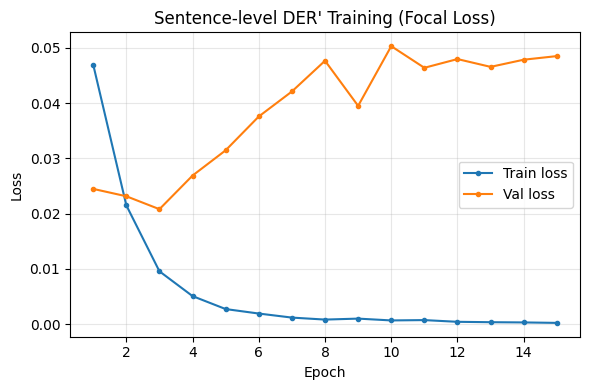

In [ ]:
# -------------------------
# 10. Training loop + best checkpoint
# -------------------------
SAVE_PATH = "/content/drive/MyDrive/DECEN/best_sentence_level_bert_focal.pt"
EPOCHS = 15
best_f1 = -1
best_epoch = -1
# LR = 2e-5
train_loss_hist, val_loss_hist, val_f1_hist = [], [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    va_loss, p, r, f1, y_true, y_pred = run_eval(model, val_loader)

    train_loss_hist.append(tr_loss)
    val_loss_hist.append(va_loss)
    val_f1_hist.append(f1)

    print(f"[Epoch {epoch:02d}] TrainLoss={tr_loss:.4f} | ValLoss={va_loss:.4f} | P={p:.4f} R={r:.4f} F1(macro)={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_epoch = epoch
        torch.save({
            "model_state": model.state_dict(),
            "tokenizer_name": MODEL_NAME,
            "label2id": label2id,
            "id2label": id2label,
            "best_f1": best_f1,
            "best_epoch": best_epoch,
            "max_len": MAX_LEN
        }, SAVE_PATH)
        print(f"  ✅ Saved best model @ epoch {best_epoch} (F1={best_f1:.4f})")

print("\nBest F1:", best_f1, "Best epoch:", best_epoch)
print("\nClassification report (val, last epoch):")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(num_classes)], digits=4))

# -------------------------
# 11. Plot loss curve (paper-style)
# -------------------------
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_loss_hist) + 1))
plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_hist, marker='o', markersize=3, label="Train loss")
plt.plot(epochs, val_loss_hist, marker='o', markersize=3, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sentence-level DER' Training (Focal Loss)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
print("Confusion matrix:\n", cm)


Confusion matrix:
 [[646  49  16  10   5]
 [ 34 107   2   2   3]
 [ 21   6  40   0   0]
 [  7   4   0  15   0]
 [  4   1   1   0  24]]


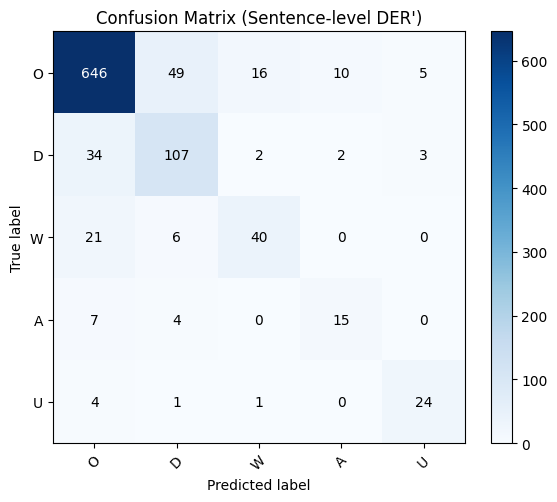

In [ ]:
import matplotlib.pyplot as plt

labels = [id2label[i] for i in range(num_classes)]

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest",cmap="Blues")
plt.title("Confusion Matrix (Sentence-level DER')")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=45)
plt.yticks(tick_marks, labels)

# 在格子中標數字
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


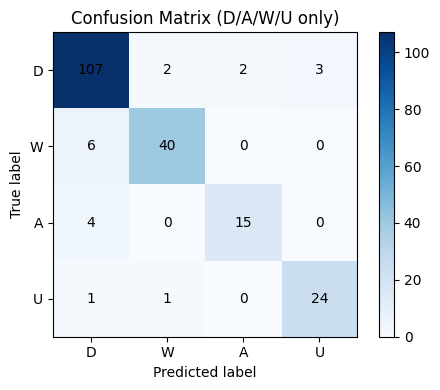

In [ ]:
# filter out O (label_id == 0)
filtered = [(t, p) for t, p in zip(y_true, y_pred) if t != label2id["O"]]

y_true_noO = [t for t, _ in filtered]
y_pred_noO = [p for _, p in filtered]

labels_noO = ["D", "W", "A", "U"]
label_ids_noO = [label2id[l] for l in labels_noO]

cm_noO = confusion_matrix(y_true_noO, y_pred_noO, labels=label_ids_noO)

plt.figure(figsize=(5, 4))
plt.imshow(cm_noO, interpolation="nearest",cmap="Blues")
plt.title("Confusion Matrix (D/A/W/U only)")
plt.colorbar()

tick_marks = np.arange(len(labels_noO))
plt.xticks(tick_marks, labels_noO)
plt.yticks(tick_marks, labels_noO)

for i in range(cm_noO.shape[0]):
    for j in range(cm_noO.shape[1]):
        plt.text(j, i, cm_noO[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()



In [ ]:
# 有早停(錯誤)
# -------------------------
# 10. Training loop + best checkpoint
# -------------------------
EPOCHS = 15
patience = 3
min_delta = 1e-4

best_f1 = -1
best_epoch = -1
no_improve = 0

SAVE_PATH = "/content/drive/MyDrive/DECEN/best_pipelineB_sentence_bert_focal.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    va_loss, p, r, f1, yt, yp = evaluate(model, val_loader)

    print(f"[Epoch {epoch:02d}] TrainLoss={tr_loss:.4f} | ValLoss={va_loss:.4f} | P={p:.4f} R={r:.4f} F1(macro)={f1:.4f}")

    if f1 > best_f1 + min_delta:
        best_f1 = f1
        best_epoch = epoch
        no_improve = 0

        torch.save({
            "model_state": model.state_dict(),
            "best_f1": best_f1,
            "best_epoch": best_epoch,
            "label2id": label2id,
            "id2label": id2label
        }, SAVE_PATH)

        print(f"  ✅ Saved best model @ epoch {best_epoch}")
    else:
        no_improve += 1
        print(f"  ⏳ No improvement ({no_improve}/{patience})")
        if no_improve >= patience:
            print(f"\n🛑 Early stopping at epoch {epoch}. Best epoch={best_epoch}, F1={best_f1:.4f}")
            break

print("\nFinal Best F1:", best_f1, "at epoch", best_epoch)
print("\nClassification report (last eval):")
print(classification_report(yt, yp, target_names=[id2label[i] for i in range(len(label2id))], digits=4))





KeyError: 'word_ids'

### POST-LEVEL WU3D



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("webifier/wu3d-dipression-detection")

print("Path to dataset files:", path)

100%|██████████| 250M/250M [00:02<00:00, 104MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/webifier/wu3d-dipression-detection/versions/1


In [ ]:
# =========================================================
# JSON (depressed/normal) -> post-level CSV
# Strategy B: length filter + random sampling (20k per class)
# + zh-Hant conversion (OpenCC)
# =========================================================

!pip -q install opencc-python-reimplemented

import os
import json
import re
import random
import pandas as pd
from opencc import OpenCC

# ========= 你要改的參數 =========
DATA_DIR = path  # kagglehub dataset_download 回傳的 path；或改成字串路徑
DEP_JSON = "depressed.json"
NOR_JSON = "normal.json"

OUT_CSV = "/content/drive/MyDrive/DECEN/post_level_wu3d.csv"
SEED = 42

# 篩選/抽樣設定（策略 B）
N_PER_CLASS = 20000      # 每類抽樣數
MIN_LEN = 5              # caption 最少字數
MAX_LEN = 200            # caption 最多字數
DROP_DUPLICATES = True   # 同一類別內重複文字去除（建議開）
REMOVE_WHITESPACE = True # 去掉多餘空白
# ==============================

random.seed(SEED)
cc = OpenCC("s2t")  # 簡體 -> 繁體

def safe_load_json(fp: str):
    with open(fp, "r", encoding="utf-8") as f:
        return json.load(f)

def normalize_text(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    if REMOVE_WHITESPACE:
        s = re.sub(r"\s+", " ", s).strip()
    return s

def to_zh_hant(s: str) -> str:
    s = normalize_text(s)
    if not s:
        return ""
    return cc.convert(s)

def flatten_users_to_posts(users, y_value: int, src_name: str):
    """
    users: list[dict] (user-level)
    return: list[dict] post-level rows
    """
    rows = []
    for u_idx, u in enumerate(users):
        tweets = u.get("tweets", []) or []
        if not isinstance(tweets, list):
            continue

        user_key = u.get("user_id") or u.get("uid") or u.get("id") or f"user{u_idx:06d}"

        for t_idx, t in enumerate(tweets):
            if not isinstance(t, dict):
                continue

            content = t.get("tweet_content", "")
            posting_time = t.get("posting_time", "")

            caption = to_zh_hant(content)
            if not caption:
                continue

            post_id = f"{src_name}_{user_key}_t{t_idx:04d}"

            rows.append({
                "post_id": post_id,
                "caption": caption,
                "y": int(y_value),
                "posting_time": posting_time
            })
    return rows

def length_filter(df: pd.DataFrame, min_len: int, max_len: int) -> pd.DataFrame:
    df = df.copy()
    df["len"] = df["caption"].astype(str).str.len()
    df = df[(df["len"] >= min_len) & (df["len"] <= max_len)].reset_index(drop=True)
    return df

def sample_n(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if len(df) < n:
        raise ValueError(
            f"可用資料不足：目前 {len(df)} 篇，但你要抽 {n} 篇。"
            f" 請放寬 MIN_LEN/MAX_LEN 或關閉 DROP_DUPLICATES。"
        )
    return df.sample(n=n, random_state=seed).reset_index(drop=True)

# ---- 1) 讀入兩個 JSON ----
dep_path = os.path.join(DATA_DIR, DEP_JSON)
nor_path = os.path.join(DATA_DIR, NOR_JSON)

depressed_users = safe_load_json(dep_path)
normal_users = safe_load_json(nor_path)

# ---- 2) 展平為貼文層級 + 簡轉繁 ----
df_dep = pd.DataFrame(flatten_users_to_posts(depressed_users, y_value=1, src_name="dep"))
df_nor = pd.DataFrame(flatten_users_to_posts(normal_users, y_value=0, src_name="nor"))

print("Raw post count:")
print("Dep:", len(df_dep))
print("Nor:", len(df_nor))

# ---- 3) 去重（可選）----
if DROP_DUPLICATES:
    df_dep = df_dep.drop_duplicates(subset=["caption"]).reset_index(drop=True)
    df_nor = df_nor.drop_duplicates(subset=["caption"]).reset_index(drop=True)

print("\nAfter drop duplicates (optional):")
print("Dep:", len(df_dep))
print("Nor:", len(df_nor))

# ---- 4) 長度過濾（策略 B）----
df_dep_f = length_filter(df_dep, MIN_LEN, MAX_LEN)
df_nor_f = length_filter(df_nor, MIN_LEN, MAX_LEN)

print("\nAfter length filter:")
print("Dep:", len(df_dep_f))
print("Nor:", len(df_nor_f))

# ---- 5) 各類別隨機抽樣 N_PER_CLASS ----
df_dep_20k = sample_n(df_dep_f, N_PER_CLASS, SEED)
df_nor_20k = sample_n(df_nor_f, N_PER_CLASS, SEED)

# ---- 6) 合併 + shuffle ----
df_out = pd.concat([df_dep_20k, df_nor_20k], ignore_index=True)
df_out = df_out.sample(frac=1, random_state=SEED).reset_index(drop=True)

# 移除輔助欄位 len（如果存在）
if "len" in df_out.columns:
    df_out = df_out.drop(columns=["len"])

print("\nFinal dataset:")
print(df_out["y"].value_counts())

# ---- 7) 輸出 CSV ----
df_out.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print("\nSaved:", OUT_CSV)
display(df_out.head(10))


Raw post count:
Dep: 403945
Nor: 1723890

After drop duplicates (optional):
Dep: 261241
Nor: 1279628

After length filter:
Dep: 230942
Nor: 1166504

Final dataset:
y
0    20000
1    20000
Name: count, dtype: int64

Saved: /content/drive/MyDrive/DECEN/post_level_wu3d.csv


,post_id,caption,y,posting_time
0,nor_user002524_t0063,走過路過不要錯過第一個出現的白衣少年全能TOP馬嘉祺讓你擁有追TOP和ACE的快樂誰追誰知道...,0,2020-05-01 20:49
1,dep_user009401_t0018,話說抽菸熬夜猝死的幾率很高 所以還是抽菸通宵吧,1,2019-06-09 02:50:25
2,nor_user010165_t0065,世界總喜歡出難題給他偏愛的孩子都能解決的睡吧晚安,0,2018-12-10 23:04:56
3,dep_user002882_t0081,狗屎工作完全不知道該怎麼幹活,1,2019-07-15 01:04:02
4,nor_user009827_t0081,這個氣氛好喜歡,0,2020-03-08 12:51
5,nor_user015219_t0048,明天后天微博我就不上啦大部分時間泡在qq和lof上順便試用一下最近攢的一些新平臺,0,2020-05-07 20:14
6,dep_user006621_t0032,喫了藥也不覺得快樂,1,2018-04-16 20:47:43
7,nor_user013124_t0044,rpq張穎即時又是一愣笑眯眯的雙眼恢復了精明不着痕跡審視着凌語芊見她嬌滴滴一看就知是個養尊處...,0,2017-10-30 13:29:22
8,dep_user000017_t0019,我爲貢獻148影響力超話目前還差45392影響力超越上一名戳這裏→ 跟我一起打榜應援愛豆提升排名吧,1,2020-02-09 14:10
9,nor_user014952_t0003,天了嚕小丑和小丑女有望出獨立電影傑瑞德萊託瑪格特羅比有望繼續出演小丑和哈莉奎茵瘋狂愚蠢的愛導...,0,2017-09-17 12:20:51
